<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
I — Initialisation : imports et configuration 
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Contexte du projet**

L'Organisation Nationale de Lutte Contre le Faux-Monnayage (ONCFM) souhaite automatiser la détection des faux billets en euros à partir de leurs caractéristiques géométriques.

**Objectif**

Construire un algorithme capable de prédire si un billet est vrai ou faux à partir de 6 mesures géométriques :
- `diagonal` : la diagonale du billet (mm)
- `height_left` : la hauteur côté gauche (mm)
- `height_right` : la hauteur côté droit (mm)
- `margin_up` : la marge supérieure (mm)
- `margin_low` : la marge inférieure (mm)
- `length` : la longueur du billet (mm)

**Données disponibles**

- `billets.csv` : 1500 billets étiquetés (1000 vrais, 500 faux) — données d'entraînement
- `billets_production.csv` : 5 billets non étiquetés — données de production à prédire

**Modèles testés**

Régression Logistique, KNN, Random Forest, K-Means

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
A — Import des librairies
</div>

In [1]:
#️⃣ ♦️ IMPORTS — centralisés (toutes les librairies du notebook)


#️⃣ ♦️ Système
import os
import warnings
warnings.filterwarnings("ignore")

#️⃣ ♦️ Manipulation des données
import numpy as np
import pandas as pd

#️⃣ ♦️ Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

#️⃣ ♦️ Statistiques
import scipy.stats as stats
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

#️⃣ ♦️ Prétraitement
from sklearn.preprocessing import StandardScaler

#️⃣ ♦️ Sélection de modèle
from sklearn.model_selection import train_test_split, GridSearchCV

#️⃣ ♦️ Modèles supervisés
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#️⃣ ♦️ Modèle non supervisé
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#️⃣ ♦️ Métriques
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, silhouette_score,
    mean_squared_error, mean_absolute_error,
    make_scorer
)

#️⃣ ♦️ Pipeline & sauvegarde
from sklearn.pipeline import Pipeline
import joblib

#️⃣ ♦️Distance
from scipy.spatial.distance import cdist

#️⃣ ♦️Visualisation patches
from matplotlib.patches import Patch

print("Toutes les librairies importées ✓")

Toutes les librairies importées ✓


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">

B — Options d'affichage

</div>

In [2]:
#️⃣ ♦️ OPTIONS D'AFFICHAGE — à exécuter avant tout graphique

#️⃣  Tableaux pandas : afficher toutes les colonnes sans troncature
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

#️⃣  Style uniforme pour tous les graphiques seaborn
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Options d'affichage configurées ✓")

Options d'affichage configurées ✓


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Chargement des fichiers 
    
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
        1- Chargement du fichier: Billets.csv
    
</div>

In [3]:
#️⃣ ♦️ Chargement du fichier principal 

df = pd.read_csv("billets.csv", sep=";")

print("Fichier billets.csv chargé")
print(f"  - Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

Fichier billets.csv chargé
  - Dimensions : 1500 lignes x 7 colonnes


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.8100,104.8600,104.9500,4.5200,2.8900,112.8300
1,True,171.4600,103.3600,103.6600,3.7700,2.9900,113.0900
2,True,172.6900,104.4800,103.5000,4.4000,2.9400,113.1600
3,True,171.3600,103.9100,103.9400,3.6200,3.0100,113.5100
4,True,171.7300,104.2800,103.4600,4.0400,3.4800,112.5400


In [4]:
#️⃣ ♦️ Types des colonnes 

df.dtypes

is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object

In [5]:
#️⃣ ♦️ Valeurs manquantes par colonne

df.isnull().sum()

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

In [6]:
#️⃣ ♦️ Vérification des doublons 

print(f"Nombre de doublons : {df.duplicated().sum()}")

Nombre de doublons : 0


In [7]:
#️⃣ ♦️ Répartition vrais / faux billets

print(df["is_genuine"].value_counts())
print(f"\nProportion faux billets : {df['is_genuine'].value_counts(normalize=True)[False]*100:.1f}%")
print(f"Proportion vrais billets : {df['is_genuine'].value_counts(normalize=True)[True]*100:.1f}%")

is_genuine
True     1000
False     500
Name: count, dtype: int64

Proportion faux billets : 33.3%
Proportion vrais billets : 66.7%


In [8]:
#️⃣ ♦️ Encodage de la variable cible — booléen vers entier
df["is_genuine"] = df["is_genuine"].astype(int)
print(f"is_genuine encodé en int ✓ — valeurs uniques : {df['is_genuine'].unique()}")

is_genuine encodé en int ✓ — valeurs uniques : [1 0]


In [9]:
#️⃣ ♦️ Assertions de blocage

assert df.shape == (1500, 7),                        "Erreur : shape inattendu"
assert df["margin_low"].isnull().sum() == 37,        "Erreur : nombre de NaN inattendu"
assert df.duplicated().sum() == 0,                   "Erreur : doublons détectés"
assert df["is_genuine"].value_counts()[1] == 1000, "Erreur : nombre de vrais billets inattendu"
assert df["is_genuine"].value_counts()[0] == 500,  "Erreur : nombre de faux billets inattendu"

print("Toutes les assertions sont validées — données conformes")

Toutes les assertions sont validées — données conformes


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
2- Chargement du fichier: billets_production.csv
    
</div>

In [10]:
#️⃣ ♦️Chargement du fichier de production

df_prod = pd.read_csv("billets_production.csv")

print("Fichier billets_production.csv chargé")
print(f"  - Dimensions : {df_prod.shape[0]} lignes x {df_prod.shape[1]} colonnes")
print(f"\nAperçu :")
display(df_prod)

Fichier billets_production.csv chargé
  - Dimensions : 5 lignes x 7 colonnes

Aperçu :


,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.7600,104.0100,103.5400,5.2100,3.3000,111.4200,A_1
1,171.8700,104.1700,104.1300,6.0000,3.3100,112.0900,A_2
2,172.0000,104.5800,104.2900,4.9900,3.3900,111.5700,A_3
3,172.4900,104.5500,104.3400,4.4400,3.0300,113.2000,A_4
4,171.6500,103.6300,103.5600,3.7700,3.1600,113.3300,A_5


In [11]:
#️⃣ ♦️ Contrôles qualité du fichier de production
print(f"Dimensions    : {df_prod.shape}")
print(f"\nTypes :")
print(df_prod.dtypes)
print(f"\nValeurs manquantes :")
print(df_prod.isnull().sum())
print(f"\nDoublons : {df_prod.duplicated().sum()}")

Dimensions    : (5, 7)

Types :
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
id               object
dtype: object

Valeurs manquantes :
diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
id              0
dtype: int64

Doublons : 0


<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
II — ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">

 A — Statistiques descriptives globales

</div>

In [12]:
#️⃣ ♦️STATISTIQUES DESCRIPTIVES GLOBALES


df.describe()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.0000,1500.0000,1500.0000,1500.0000,1463.0000,1500.0000,1500.0000
mean,0.6667,171.9584,104.0295,103.9203,4.4860,3.1515,112.6785
std,0.4716,0.3052,0.2995,0.3256,0.6638,0.2318,0.8727
min,0.0000,171.0400,103.1400,102.8200,2.9800,2.2700,109.4900
25%,0.0000,171.7500,103.8200,103.7100,4.0150,2.9900,112.0300
50%,1.0000,171.9600,104.0400,103.9200,4.3100,3.1400,112.9600
75%,1.0000,172.1700,104.2300,104.1500,4.8700,3.3100,113.3400
max,1.0000,173.0100,104.8800,104.9500,6.9000,3.9100,114.4400


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">

B — Statistiques par classe True vs False

</div>

In [13]:
#️⃣ ♦️ MOYENNES PAR CLASSE — vrais vs faux billets


df.groupby("is_genuine").mean().round(4)

,diagonal,height_left,height_right,margin_low,margin_up,length
is_genuine,,,,,,
0,171.9012,104.1903,104.1436,5.2159,3.3502,111.6306
1,171.9871,103.9491,103.8086,4.1161,3.0521,113.2024


<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Résultat :**

Faux billets:   length = 111.63
Vrais billets:  length = 113.20
On observe déjà que :  les vrais billets sont en moyenne plus longs.

Autre exemple :
Faux billets:    margin_low = 5.21
Vrais billets:   margin_low = 4.12
Les faux billets ont une marge basse plus grande.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Visualisations : distributions et séparation des classes
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
1 — Distribution de la variable cible (vrais vs faux)
</div>

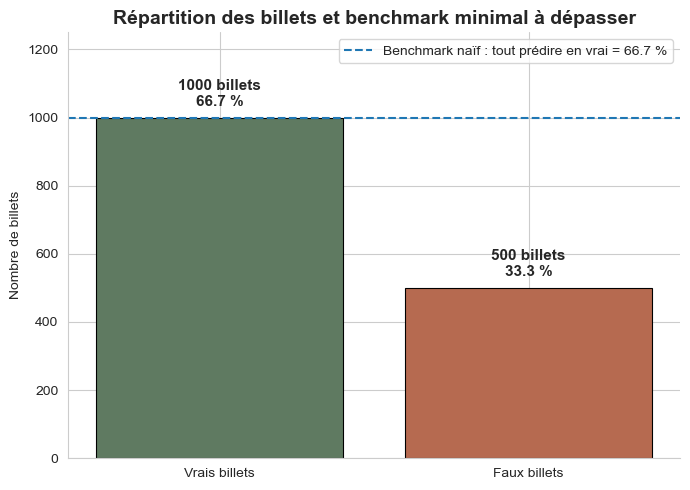

Graphique sauvegardé : Répartition des billets et benchmark minimal à dépasser ✓


In [14]:
#️⃣ ♦️ Distribution de la variable cible (vrais vs faux)


counts = df["is_genuine"].value_counts()
total  = len(df)

data = {
    "Vrais billets": counts[1],
    "Faux billets" : counts[0]
}

percentages = {k: v / total * 100 for k, v in data.items()}
benchmark   = counts[1] / total * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    data.keys(),
    data.values(),
    color=["#5F7A61", "#B66A50"],
    edgecolor="black",
    linewidth=0.8
)

for bar, (label, value) in zip(bars, data.items()):
    pct = percentages[label]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 25,
        f"{value} billets\n{pct:.1f} %",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.axhline(
    y=counts[1],
    linestyle="--",
    linewidth=1.5,
    label=f"Benchmark naïf : tout prédire en vrai = {benchmark:.1f} %"
)

ax.set_title("Répartition des billets et benchmark minimal à dépasser",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Nombre de billets")
ax.set_ylim(0, max(data.values()) * 1.25)
ax.legend(loc="upper right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Répartition des billets et benchmark minimal à dépasser",
            dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : Répartition des billets et benchmark minimal à dépasser ✓")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
2 — Boxplots des 6 variables par classe
</div>

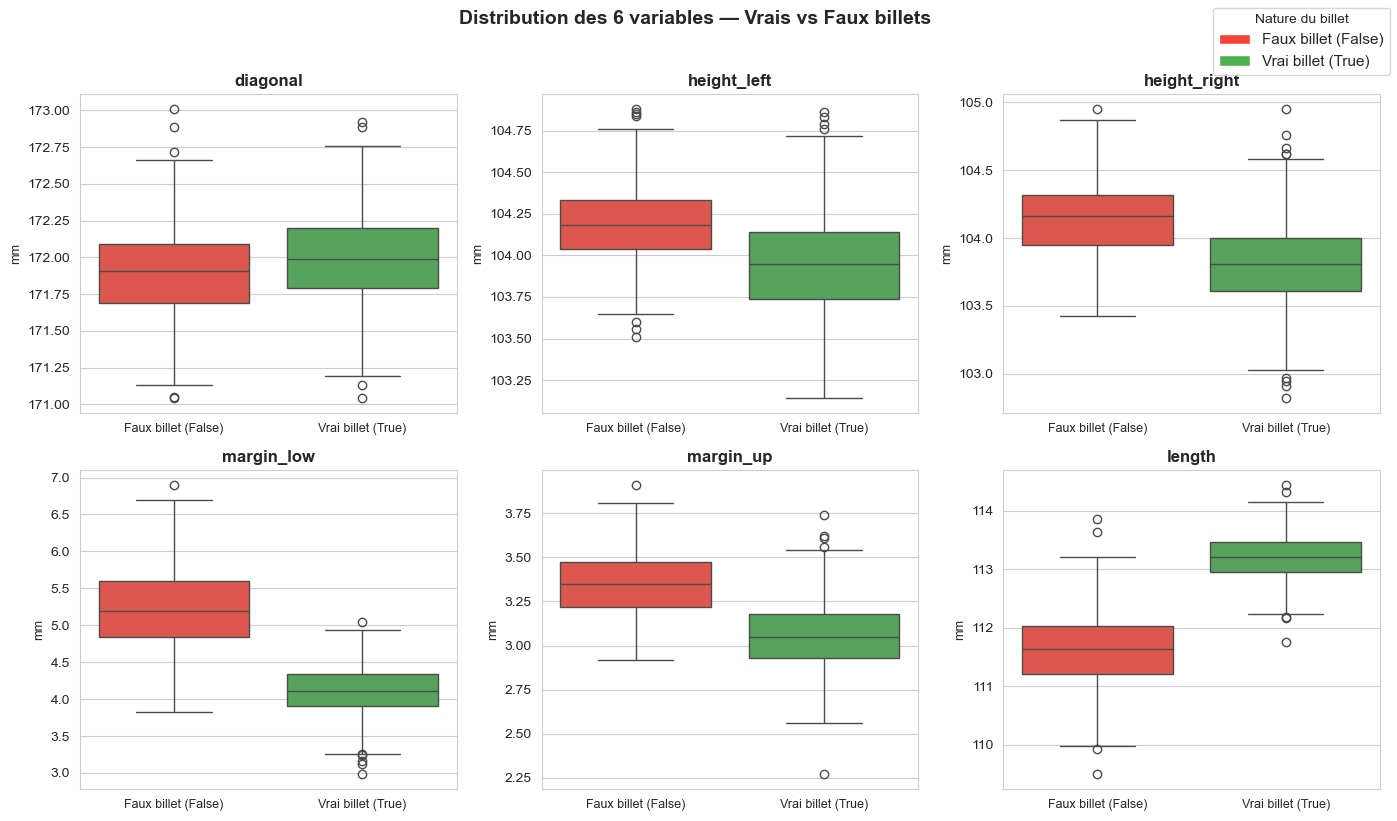

In [15]:
#️⃣ ♦️ BOXPLOTS PAR CLASSE — vrais vs faux billets (grille 2x3)
variables = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.boxplot(x="is_genuine", y=var, data=df, ax=axes[i],
                palette=["#f44336", "#4caf50"])
    axes[i].set_title(var, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("mm", fontsize=9)
    axes[i].set_xticklabels(["Faux billet (False)", "Vrai billet (True)"], fontsize=9)

#️⃣  Légende manuelle
from matplotlib.patches import Patch
legende = [Patch(facecolor="#f44336", label="Faux billet (False)"),
           Patch(facecolor="#4caf50", label="Vrai billet (True)")]
fig.legend(handles=legende, loc="upper right", fontsize=11, title="Nature du billet")

plt.suptitle("Distribution des 6 variables — Vrais vs Faux billets",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("boxplots_vrais_vs_faux.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
#️⃣ ♦️ ÉCART EN % ENTRE FAUX ET VRAIS BILLETS


moyennes  = df.groupby("is_genuine").mean()
ecart_pct = ((moyennes.loc[0] - moyennes.loc[1]) / moyennes.loc[1] * 100).round(2)

ecart_pct.to_frame(name="Écart Faux vs Vrais (%)").sort_values("Écart Faux vs Vrais (%)", ascending=False)

,Écart Faux vs Vrais (%)
margin_low,26.7200
margin_up,9.7600
height_right,0.3200
height_left,0.2300
diagonal,-0.0500
length,-1.3900


<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Résultat :**

Les boxplots montrent que les variables length, margin_low et margin_up séparent nettement les vrais et les faux billets, tandis que diagonal paraît beaucoup moins informative."
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
3 — Corrélation des variables avec la cible (is_genuine)
</div>

In [17]:
#️⃣ ♦️ Corrélation de chaque variable avec la cible 

#️⃣ ♦️Définir la liste des variables explicatives

features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]
corr_avec_cible = df[features + ["is_genuine"]].corr()
print("\nCorrélation avec is_genuine (1=vrai, 0=faux) :")
print(corr_avec_cible["is_genuine"].sort_values(ascending=False))


Corrélation avec is_genuine (1=vrai, 0=faux) :
is_genuine      1.0000
length          0.8493
diagonal        0.1328
height_left    -0.3798
height_right   -0.4851
margin_up      -0.6063
margin_low     -0.7830
Name: is_genuine, dtype: float64


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
4 — Visualisation : corrélation avec la cible
</div>

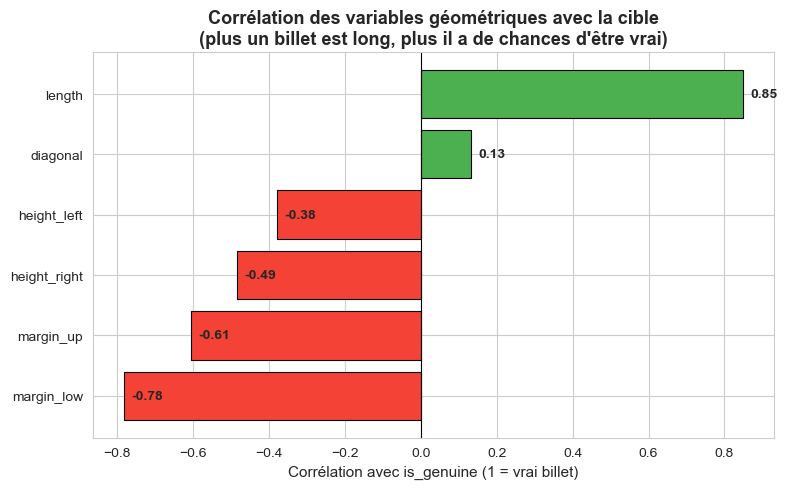

In [18]:
#️⃣ ♦️ Graphique des corrélations avec la cible
corr_cible = corr_avec_cible["is_genuine"].drop("is_genuine").sort_values(ascending=False)

plt.figure(figsize=(8, 5))
couleurs = ["#4caf50" if x > 0 else "#f44336" for x in corr_cible.values]
bars = plt.barh(corr_cible.index, corr_cible.values, color=couleurs, edgecolor="black", linewidth=0.8)

# Inverser l'axe Y pour que la plus forte corrélation soit en haut
plt.gca().invert_yaxis()

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, corr_cible.values):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=10, fontweight="bold")

#️⃣  Ligne verticale à 0
plt.axvline(x=0, color="black", linewidth=0.8, linestyle="-")

#️⃣  Étiquettes
plt.xlabel("Corrélation avec is_genuine (1 = vrai billet)", fontsize=11)
plt.title("Corrélation des variables géométriques avec la cible\n(plus un billet est long, plus il a de chances d'être vrai)", 
          fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("correlation_avec_cible.png", dpi=150, bbox_inches="tight")
plt.show()

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
5 — Matrice de corrélation
</div>

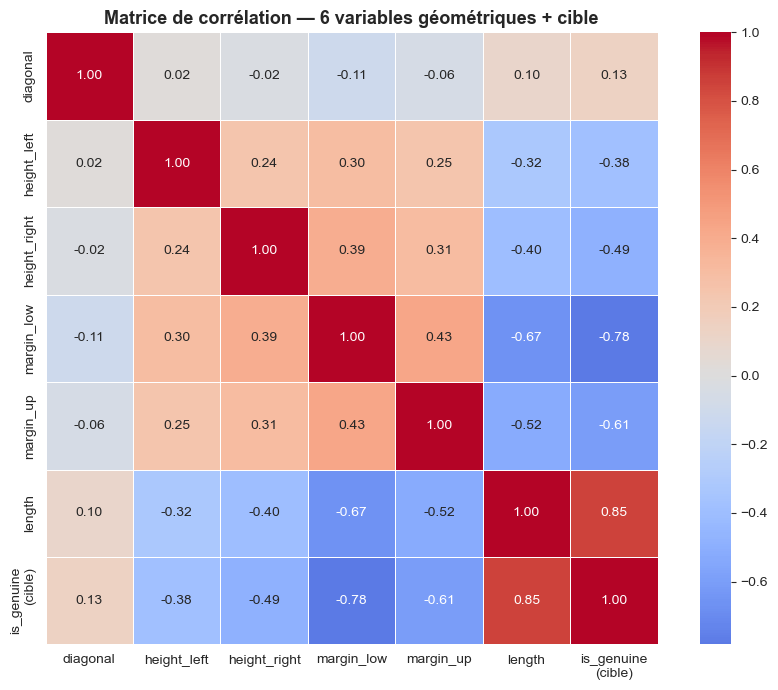

In [19]:
#️⃣ ♦️ MATRICE DE CORRÉLATION — 6 variables + is_genuine

#️⃣  is_genuine inclus pour visualiser la corrélation avec la cible
colonnes = ["diagonal", "height_left", "height_right",
            "margin_low", "margin_up", "length", "is_genuine"]

corr = df[colonnes].corr()

#️⃣  Renommer is_genuine pour l'affichage
corr.index   = [c if c != "is_genuine" else "is_genuine\n(cible)" for c in corr.index]
corr.columns = [c if c != "is_genuine" else "is_genuine\n(cible)" for c in corr.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Matrice de corrélation — 6 variables géométriques + cible",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
6 — margin_low vs chaque variable explicative
</div>

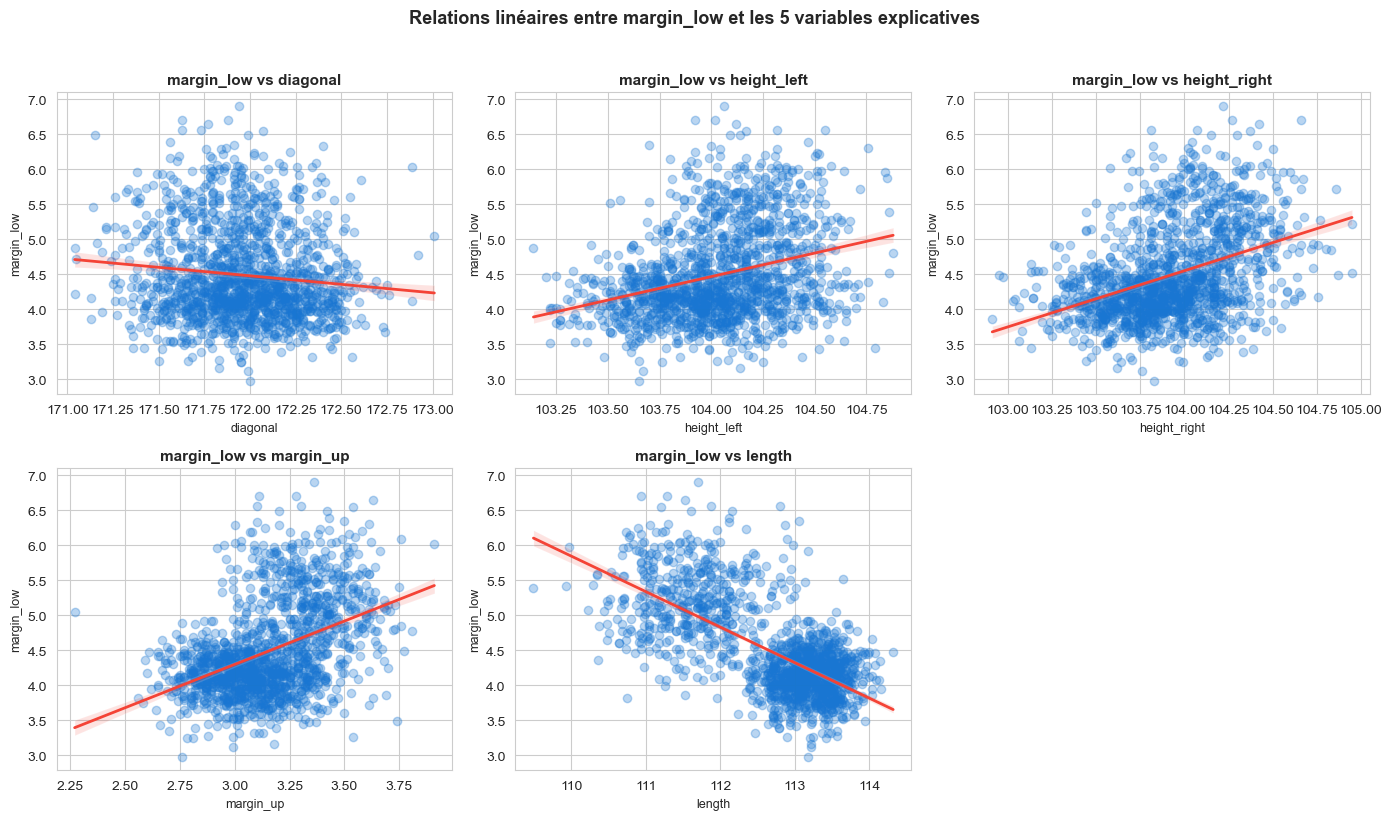

Graphique sauvegardé : scatterplots_margin_low.png ✓


In [20]:
#️⃣ ♦️ Scatterplots — margin_low vs chaque variable explicative

features_scatter = ["diagonal", "height_left", "height_right", "margin_up", "length"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(features_scatter):
    sns.regplot(x=var, y="margin_low", data=df,
                ax=axes[i],
                scatter_kws={"alpha": 0.3, "color": "#1976d2"},
                line_kws={"color": "#f44336", "linewidth": 2})
    axes[i].set_title(f"margin_low vs {var}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(var, fontsize=9)
    axes[i].set_ylabel("margin_low", fontsize=9)

axes[5].set_visible(False)

plt.suptitle("Relations linéaires entre margin_low et les 5 variables explicatives",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("scatterplots_margin_low.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : scatterplots_margin_low.png ✓")

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
III — PRÉPARATION DES DONNÉES : IMPUTATION DES VALEURS MANQUANTES
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
A — Régression linéaire simple : margin_low ~ length
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

<strong>Note méthodologique — Métriques calculées sur les données d'entraînement</strong><br><br>

Les métriques RMSE, MAE et R² sont calculées sur les données d'entraînement
(<code>df_train</code>), car les valeurs cibles du jeu de test (<code>df_test</code>)
sont précisément les 37 valeurs manquantes de <code>margin_low</code> que l'on cherche à imputer.<br><br>

Il est donc <strong>impossible</strong> d'évaluer le modèle sur un jeu de test indépendant
dans ce contexte : il n'existe pas de valeur réelle à laquelle comparer la prédiction.<br><br>

Les métriques servent uniquement à <strong>comparer les 3 modèles entre eux</strong>
afin de sélectionner le meilleur modèle d'imputation.

</div>

In [21]:
#️⃣ ♦️ OLS statsmodels — régression simple : margin_low ~ length


df_train = df[df["margin_low"].notna()].copy()
df_test  = df[df["margin_low"].isna()].copy()

X_simple_train = df_train["length"]
y_train        = df_train["margin_low"]

X_simple_test  = df_test["length"]

ols_simple = sm.OLS(y_train, X_simple_train).fit()

print("=" * 60)
print("   RÉGRESSION LINÉAIRE SIMPLE — margin_low ~ length")
print("=" * 60)
print(ols_simple.summary())

   RÉGRESSION LINÉAIRE SIMPLE — margin_low ~ length
                                 OLS Regression Results                                
Dep. Variable:             margin_low   R-squared (uncentered):                   0.977
Model:                            OLS   Adj. R-squared (uncentered):              0.977
Method:                 Least Squares   F-statistic:                          6.220e+04
Date:                Wed, 17 Jun 2026   Prob (F-statistic):                        0.00
Time:                        11:43:41   Log-Likelihood:                         -1527.2
No. Observations:                1463   AIC:                                      3056.
Df Residuals:                    1462   BIC:                                      3062.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025  

In [22]:
#️⃣ ♦️ Métriques — régression simple : margin_low ~ length

y_pred_simple = ols_simple.fittedvalues

rmse_simple = np.sqrt(mean_squared_error(y_train, y_pred_simple))
mae_simple  = mean_absolute_error(y_train, y_pred_simple)
r2_simple   = ols_simple.rsquared

print("=== Régression linéaire SIMPLE (length seul) ===")
print(f"  RMSE : {rmse_simple:.4f}")
print(f"  MAE  : {mae_simple:.4f}")
print(f"  R²   : {r2_simple:.4f}")
print(f"\n  Coefficient length : {ols_simple.params['length']:.4f}")

=== Régression linéaire SIMPLE (length seul) ===
  RMSE : 0.6872
  MAE  : 0.5518
  R²   : 0.9770

  Coefficient length : 0.0398


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
B — régression multiple : margin_low ~ 5 variables
</div>

In [23]:
#️⃣ ♦️ OLS statsmodels — régression multiple : margin_low ~ 5 variables

features_ols = ["diagonal", "height_left", "height_right", "margin_up", "length"]

X_multiple_train = df_train[features_ols]
X_multiple_test  = df_test[features_ols]

ols_multiple = sm.OLS(y_train, X_multiple_train).fit()

print("=" * 60)
print("   RÉGRESSION LINÉAIRE MULTIPLE — margin_low ~ 5 variables")
print("=" * 60)
print(ols_multiple.summary())

   RÉGRESSION LINÉAIRE MULTIPLE — margin_low ~ 5 variables
                                 OLS Regression Results                                
Dep. Variable:             margin_low   R-squared (uncentered):                   0.989
Model:                            OLS   Adj. R-squared (uncentered):              0.989
Method:                 Least Squares   F-statistic:                          2.566e+04
Date:                Wed, 17 Jun 2026   Prob (F-statistic):                        0.00
Time:                        11:43:41   Log-Likelihood:                         -1004.2
No. Observations:                1463   AIC:                                      2018.
Df Residuals:                    1458   BIC:                                      2045.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|     

In [24]:
#️⃣ ♦️ Métriques — régression multiple : margin_low ~ 5 variables

y_pred_multiple = ols_multiple.fittedvalues

rmse_multiple = np.sqrt(mean_squared_error(y_train, y_pred_multiple))
mae_multiple  = mean_absolute_error(y_train, y_pred_multiple)
r2_multiple   = ols_multiple.rsquared

print("=== Régression linéaire MULTIPLE (5 variables) ===")
print(f"  RMSE : {rmse_multiple:.4f}")
print(f"  MAE  : {mae_multiple:.4f}")
print(f"  R²   : {r2_multiple:.4f}")
print(f"\n  Variable non significative : diagonal (p = 0.151)")
print(f"  Multicolinéarité détectée  : Cond. No. = 1.31e+03")

=== Régression linéaire MULTIPLE (5 variables) ===
  RMSE : 0.4807
  MAE  : 0.3726
  R²   : 0.9888

  Variable non significative : diagonal (p = 0.151)
  Multicolinéarité détectée  : Cond. No. = 1.31e+03


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Régression linéaire simple : margin_low ~ length + is_genuine
</div>

In [25]:
#️⃣ ♦️OLS statsmodels — modèle retenu : margin_low ~ length + is_genuine

df_train["is_genuine"] = df_train["is_genuine"].astype(int)
df_test["is_genuine"]  = df_test["is_genuine"].astype(int)

features_ols3 = ["length", "is_genuine"]

X_ols3_train = df_train[features_ols3]
X_ols3_test  = df_test[features_ols3]
y_ols3_train = df_train["margin_low"]

ols3 = sm.OLS(y_ols3_train, X_ols3_train).fit()

print("=" * 60)
print("   RÉGRESSION — margin_low ~ length + is_genuine")
print("=" * 60)
print(ols3.summary())

   RÉGRESSION — margin_low ~ length + is_genuine
                                 OLS Regression Results                                
Dep. Variable:             margin_low   R-squared (uncentered):                   0.992
Model:                            OLS   Adj. R-squared (uncentered):              0.992
Method:                 Least Squares   F-statistic:                          8.719e+04
Date:                Wed, 17 Jun 2026   Prob (F-statistic):                        0.00
Time:                        11:43:41   Log-Likelihood:                         -783.44
No. Observations:                1463   AIC:                                      1571.
Df Residuals:                    1461   BIC:                                      1581.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025     

In [26]:
#️⃣ ♦️ Métriques — modèle retenu : margin_low ~ length + is_genuine

y_pred_ols3 = ols3.fittedvalues

rmse_ols3 = np.sqrt(mean_squared_error(y_ols3_train, y_pred_ols3))
mae_ols3  = mean_absolute_error(y_ols3_train, y_pred_ols3)
r2_ols3   = ols3.rsquared

print("=== Régression — length + is_genuine (modèle retenu) ===")
print(f"  RMSE : {rmse_ols3:.4f}")
print(f"  MAE  : {mae_ols3:.4f}")
print(f"  R²   : {r2_ols3:.4f}")
print(f"\n  Coefficient length     : {ols3.params['length']:.4f}")
print(f"  Coefficient is_genuine : {ols3.params['is_genuine']:.4f}")
print(f"  Toutes variables significatives (p = 0.000)")
print(f"  Pas de multicolinéarité : Cond. No. = 241")

=== Régression — length + is_genuine (modèle retenu) ===
  RMSE : 0.4134
  MAE  : 0.3168
  R²   : 0.9917

  Coefficient length     : 0.0467
  Coefficient is_genuine : -1.1730
  Toutes variables significatives (p = 0.000)
  Pas de multicolinéarité : Cond. No. = 241


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
D - Tableau comparatif des 3 modèles OLS
</div>

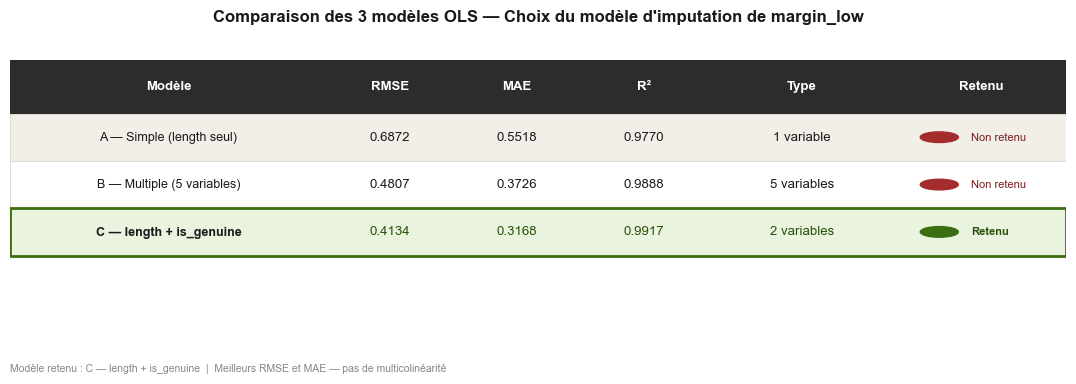

Tableau sauvegardé : tableau_comparatif_ols.png ✓


In [27]:
#️⃣ ♦️ Tableau comparatif des 3 modèles OLS
donnees = [
    {"methode": "A — Simple (length seul)",   "rmse": rmse_simple,   "mae": mae_simple,
     "r2": r2_simple,   "type": "1 variable",  "retenu": False},
    {"methode": "B — Multiple (5 variables)", "rmse": rmse_multiple, "mae": mae_multiple,
     "r2": r2_multiple, "type": "5 variables", "retenu": False},
    {"methode": "C — length + is_genuine",    "rmse": rmse_ols3,     "mae": mae_ols3,
     "r2": r2_ols3,     "type": "2 variables", "retenu": True},
]
COL_X = [0.00, 0.30, 0.42, 0.54, 0.67, 0.85]
COL_W = [0.30, 0.12, 0.12, 0.12, 0.16, 0.14]
ENTETES = ["Modèle", "RMSE", "MAE", "R²", "Type", "Retenu"]
fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor('#FFFFFF')
fig.subplots_adjust(top=0.82, bottom=0.08, left=0.02, right=0.98)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.text(0.5, 1.12,
        "Comparaison des 3 modèles OLS — Choix du modèle d'imputation de margin_low",
        ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='#1a1a1a',
        transform=ax.transAxes)
H_ENT = 0.18
H_LIG = 0.16
y_ent = 0.82
#️⃣  En-tête
ax.add_patch(patches.FancyBboxPatch(
    (0, y_ent), 1.0, H_ENT,
    boxstyle="square,pad=0",
    linewidth=0, facecolor='#2C2C2A', zorder=1))
for cx, cw, label in zip(COL_X, COL_W, ENTETES):
    ax.text(cx + cw/2, y_ent + H_ENT/2, label,
            ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='#FFFFFF', zorder=2)
#️⃣ Lignes
for idx, d in enumerate(donnees):
    y = y_ent - (idx + 1) * H_LIG
    bg = '#EAF3DE' if d["retenu"] else ('#F1EFE8' if idx % 2 == 0 else '#FFFFFF')
    ax.add_patch(patches.FancyBboxPatch(
        (0, y), 1.0, H_LIG,
        boxstyle="square,pad=0",
        linewidth=2.0 if d["retenu"] else 0.5,
        edgecolor='#3B6D11' if d["retenu"] else '#D3D1C7',
        facecolor=bg, zorder=1))
    valeurs = [d["methode"],
               f"{d['rmse']:.4f}",
               f"{d['mae']:.4f}",
               f"{d['r2']:.4f}",
               d["type"],
               None]
    for i, (cx, cw, val) in enumerate(zip(COL_X, COL_W, valeurs)):
        if val is None:
            cx_mid = cx + cw / 2
            cy_mid = y + H_LIG / 2
            ax.add_patch(plt.Circle(
                (cx_mid - 0.04, cy_mid), 0.018,
                color='#3B6D11' if d["retenu"] else '#A32D2D',
                zorder=3))
            ax.text(cx_mid - 0.01, cy_mid,
                    "Retenu" if d["retenu"] else "Non retenu",
                    ha='left', va='center', fontsize=8,
                    color='#27500A' if d["retenu"] else '#791F1F',
                    fontweight='bold' if d["retenu"] else 'normal',
                    zorder=3)
        else:
            ax.text(cx + cw/2, y + H_LIG/2, val,
                    ha='center', va='center',
                    fontsize=9 if i == 0 else 9.5,
                    fontweight='bold' if (i == 0 and d["retenu"]) else 'normal',
                    color='#27500A' if (d["retenu"] and i > 0) else '#1a1a1a',
                    zorder=2)
ax.text(0.0, -0.06,
        "Modèle retenu : C — length + is_genuine  |  Meilleurs RMSE et MAE — pas de multicolinéarité",
        ha='left', va='bottom', fontsize=7.5, color='#888780',
        transform=ax.transAxes)
plt.savefig("tableau_comparatif_ols.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Tableau sauvegardé : tableau_comparatif_ols.png ✓")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
1 — Validation des conditions du modèle linéaire — OLS3

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
a — Validation des conditions du modèle linéaire — OLS3
</div>

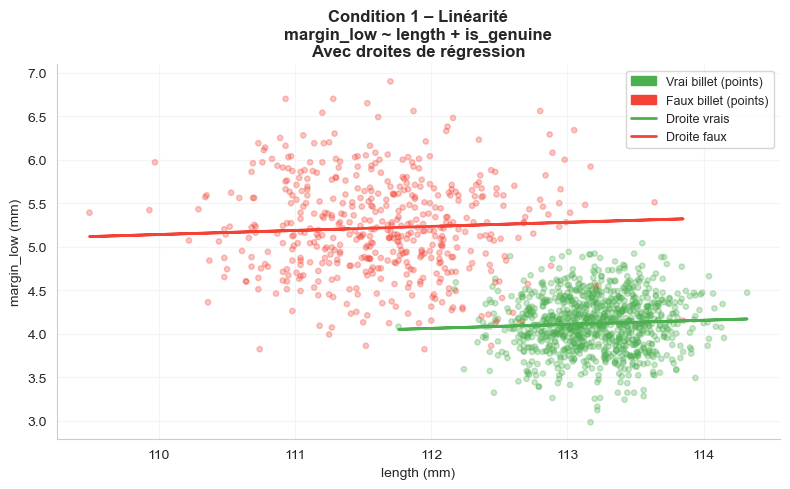

Graphique sauvegardé avec les droites de régression (coefficients issus de ols3)


In [28]:
#️⃣ ♦️ Condition 1: Linéarité - Vérification sur le modèle ols3 : margin_low ~ length + is_genuine

fig, ax = plt.subplots(figsize=(8, 5))

#️⃣ Couleurs : vrai (vert), faux (rouge)
couleurs_train = df_train["is_genuine"].map({1: "#4caf50", 0: "#f44336"})

#️⃣ Nuage de points
ax.scatter(df_train["length"], df_train["margin_low"],
    c=couleurs_train, alpha=0.3, s=15)

#️⃣ Récupération automatique des coefficients du modèle ols3

coef_length = ols3.params["length"]
coef_is_genuine = ols3.params["is_genuine"]

#️⃣ Tracer la droite de régression pour les vrais (is_genuine = 1)
df_vrais = df_train[df_train["is_genuine"] == 1]
x_vrais = df_vrais["length"]
y_vrais_predits = coef_length * x_vrais + coef_is_genuine * 1
ax.plot(x_vrais, y_vrais_predits, color="#4caf50", linewidth=2, label="Droite vrais")

#️⃣ Tracer la droite de régression pour les faux (is_genuine = 0)
df_faux = df_train[df_train["is_genuine"] == 0]
x_faux = df_faux["length"]
y_faux_predits = coef_length * x_faux + coef_is_genuine * 0
ax.plot(x_faux, y_faux_predits, color="#f44336", linewidth=2, label="Droite faux")


#️⃣ Personnalisation du graphique

ax.set_xlabel("length (mm)", fontsize=10)
ax.set_ylabel("margin_low (mm)", fontsize=10)
ax.set_title("Condition 1 – Linéarité\nmargin_low ~ length + is_genuine\nAvec droites de régression", 
             fontsize=12, fontweight="bold")

ax.legend(handles=[
    Patch(color="#4caf50", label="Vrai billet (points)"),
    Patch(color="#f44336", label="Faux billet (points)"),
    plt.Line2D([0], [0], color="#4caf50", linewidth=2, label="Droite vrais"),
    plt.Line2D([0], [0], color="#f44336", linewidth=2, label="Droite faux")
], fontsize=9)

ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("condition1_linearite_avec_droites.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé avec les droites de régression (coefficients issus de ols3)")

<div style="background-color: #fff8e1; padding: 12px; border-left: 5px solid #f9a825; border-radius: 6px;">
<strong>Résultat — Condition 1 validée ✓</strong><br><br>

Les deux nuages de points sont clairement séparés :
les vrais billets (vert) se concentrent sur des longueurs plus élevées avec des valeurs de <code>margin_low</code> plus faibles,
tandis que les faux billets (rouge) présentent des longueurs plus courtes et des valeurs de <code>margin_low</code> plus élevées.

Aucune relation courbe évidente n'apparaît entre <code>length</code> et <code>margin_low</code>.
L'hypothèse de linéarité du modèle <code>margin_low ~ length + is_genuine</code> paraît donc raisonnable.
</div>

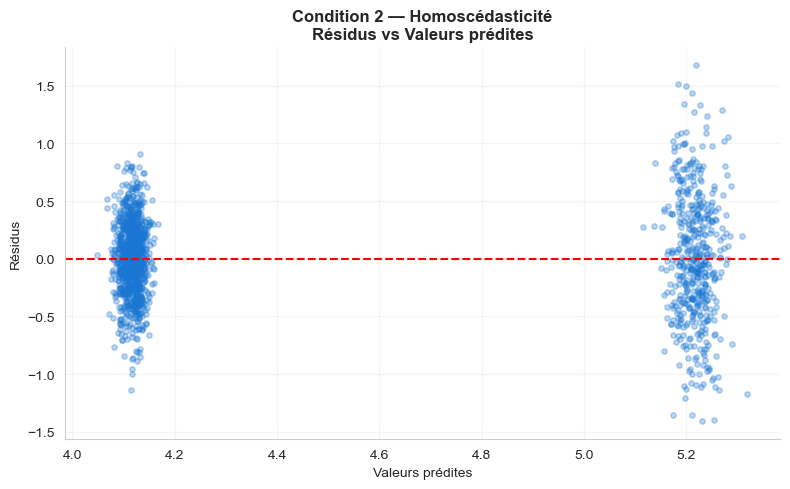

Graphique sauvegardé ✓


In [29]:
#️⃣ ♦️ Condition 2 — Homoscédasticité

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ols3.fittedvalues, ols3.resid, alpha=0.3, color="#1976d2", s=15)
ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
ax.set_xlabel("Valeurs prédites", fontsize=10)
ax.set_ylabel("Résidus", fontsize=10)
ax.set_title("Condition 2 — Homoscédasticité\nRésidus vs Valeurs prédites",
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("condition2_homoscedasticite.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé ✓")

<div style="background-color: #fff8e1; padding: 12px; border-left: 5px solid #f9a825; border-radius: 6px;">
<strong>Résultat — Condition 2 globalement acceptable ✓</strong><br><br>

Les résidus sont globalement répartis autour de 0 et ne forment pas de courbe ni d'entonnoir marqué.
On observe deux groupes de valeurs prédites, ce qui est cohérent avec l'effet de la variable <code>is_genuine</code> dans le modèle.

L'hypothèse d'homoscédasticité paraît donc acceptable, même si la dispersion semble légèrement plus forte pour l'un des deux groupes.
</div>

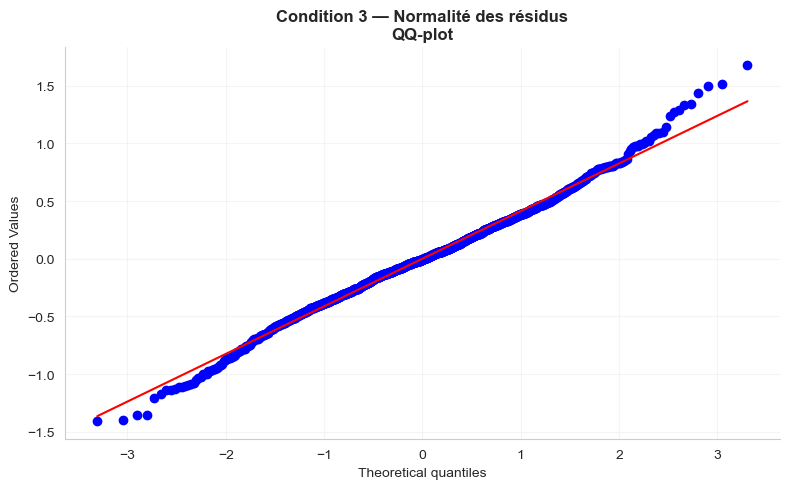

Graphique sauvegardé ✓


In [30]:
#️⃣ ♦️ Condition 3 — Normalité des résidus

fig, ax = plt.subplots(figsize=(8, 5))
stats.probplot(ols3.resid, dist="norm", plot=ax)
ax.set_title("Condition 3 — Normalité des résidus\nQQ-plot",
             fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("condition3_normalite.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé ✓")

<div style="background-color: #fff8e1; padding: 12px; border-left: 5px solid #f9a825; border-radius: 6px;">
<strong>Résultat — Condition 3 validée ✓</strong><br><br>

Les points suivent globalement la diagonale rouge, surtout au centre du graphique.
Les légères déviations aux extrémités restent limitées et sont acceptables avec un grand nombre d'observations.

Les résidus sont donc globalement compatibles avec une distribution normale.
</div>

In [31]:
#️⃣ ♦️ Condition 4 — Multicolinéarité — calcul du VIF

X_vif = df_train[["length", "is_genuine"]].copy()

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"]      = [variance_inflation_factor(X_vif.values, i)
                        for i in range(X_vif.shape[1])]

print("=== Condition 4 — Multicolinéarité (VIF) ===")
print(vif_data.to_string(index=False))
print("\nRègle : VIF < 5 → pas de multicolinéarité problématique")

=== Condition 4 — Multicolinéarité (VIF) ===
  Variable    VIF
    length 3.0294
is_genuine 3.0294

Règle : VIF < 5 → pas de multicolinéarité problématique


<div style="background-color: #fff8e1; padding: 12px; border-left: 5px solid #f9a825; border-radius: 6px;">
<strong>Résultat — Condition 4 validée ✓</strong><br><br>

Les deux variables <code>length</code> et <code>is_genuine</code> présentent un VIF de 3.03, inférieur au seuil de 5 au-delà duquel la multicolinéarité devient problématique.
Les variables explicatives n'apportent donc pas d'information redondante l'une par rapport à l'autre.

Les coefficients du modèle <code>margin_low ~ length + is_genuine</code> sont par conséquent stables et interprétables, sans gonflement artificiel de leur variance.
</div>

In [32]:
#️⃣ ♦️ Condition 5 — Indépendance des résidus (autocorrélation) — Durbin-Watson

#️⃣ Calcul du statistique sur les résidus du modèle retenu ols3
dw_stat = durbin_watson(ols3.resid)

print("=== Condition 5 — Indépendance des résidus (Durbin-Watson) ===")
print(f"Durbin-Watson : {dw_stat:.4f}")
print()
print("Règle d'interprétation :")
print("  DW ≈ 2      → résidus indépendants (aucune autocorrélation) ✓")
print("  DW → 0      → autocorrélation positive")
print("  DW → 4      → autocorrélation négative")
print()

if 1.5 <= dw_stat <= 2.5:
    print(f"→ DW = {dw_stat:.2f} ≈ 2 : condition d'indépendance VALIDÉE ✓")
else:
    print(f"→ DW = {dw_stat:.2f} : autocorrélation possible — à examiner")

=== Condition 5 — Indépendance des résidus (Durbin-Watson) ===
Durbin-Watson : 2.0311

Règle d'interprétation :
  DW ≈ 2      → résidus indépendants (aucune autocorrélation) ✓
  DW → 0      → autocorrélation positive
  DW → 4      → autocorrélation négative

→ DW = 2.03 ≈ 2 : condition d'indépendance VALIDÉE ✓


<div style="background-color: #fff8e1; padding: 12px; border-left: 5px solid #f9a825; border-radius: 6px;">
<strong>Résultat — Condition 5 validée ✓</strong><br><br>

La statistique de Durbin-Watson vaut 2.03, très proche de la valeur idéale de 2.
Les résidus du modèle <code>margin_low ~ length + is_genuine</code> ne présentent donc aucune autocorrélation : chaque erreur de prédiction est indépendante des autres.

L'hypothèse d'indépendance des résidus est respectée, confirmant la validité du modèle OLS retenu pour l'imputation de <code>margin_low</code>.
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
E — Imputation finale des 37 valeurs manquantes
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
1 — Application du modèle OLS3 retenu aux 37 valeurs manquantes
</div>

In [33]:
#️⃣ ♦️ Réentraînement OLS final sur tout df_complet + imputation df_nan

y_imputed = ols3.predict(X_ols3_test)

df.loc[df["margin_low"].isna(), "margin_low"] = y_imputed.values

print(f"Valeurs manquantes restantes : {df['margin_low'].isna().sum()}")
print(f"Shape final : {df.shape}")
print("Imputation terminée ✓")

Valeurs manquantes restantes : 0
Shape final : (1500, 7)
Imputation terminée ✓


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
2 — Vérification du dataset complet
</div>

In [34]:
#️⃣ ♦️ Vérification — plus aucun NaN, dataset prêt pour la modélisation

assert df["margin_low"].isnull().sum() == 0, "Erreur : NaN restants"
assert df.shape == (1500, 7), "Erreur : shape inattendu"

print("Dataset complet — aucun NaN ✓")
df.describe().round(4)

Dataset complet — aucun NaN ✓


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.0000,1500.0000,1500.0000,1500.0000,1500.0000,1500.0000,1500.0000
mean,0.6667,171.9584,104.0295,103.9203,4.4827,3.1515,112.6785
std,0.4716,0.3052,0.2995,0.3256,0.6597,0.2318,0.8727
min,0.0000,171.0400,103.1400,102.8200,2.9800,2.2700,109.4900
25%,0.0000,171.7500,103.8200,103.7100,4.0300,2.9900,112.0300
50%,1.0000,171.9600,104.0400,103.9200,4.3100,3.1400,112.9600
75%,1.0000,172.1700,104.2300,104.1500,4.8700,3.3100,113.3400
max,1.0000,173.0100,104.8800,104.9500,6.9000,3.9100,114.4400


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
3 — Vérification post-imputation — distribution de margin_low
</div>

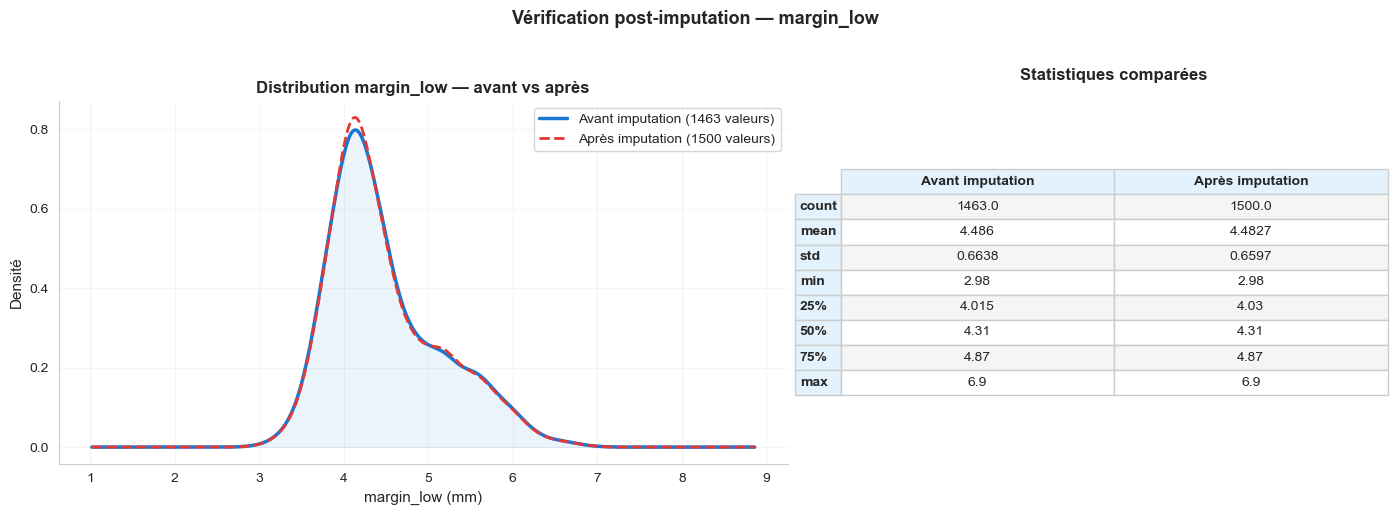

Graphique sauvegardé : verification_imputation.png ✓


In [35]:
#️⃣ ♦️ Vérification post-imputation — distribution avant vs après

#️⃣  margin_avant = les 1463 valeurs connues avant imputation
margin_avant = df_train["margin_low"]

#️⃣  margin_apres = les 1500 valeurs après imputation
margin_apres = df["margin_low"]

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1])

#️⃣  Subplot 1 : KDE avant vs après
ax1 = fig.add_subplot(gs[0])
margin_avant.plot.kde(ax=ax1, color="#1976d2", linewidth=2.5,
                      label=f"Avant imputation ({len(margin_avant)} valeurs)")
margin_apres.plot.kde(ax=ax1, color="#e53935", linewidth=2,
                      linestyle="--",
                      label=f"Après imputation ({len(margin_apres)} valeurs)")

ax1.fill_between(
    ax1.lines[0].get_xdata(),
    ax1.lines[0].get_ydata(),
    alpha=0.08, color="#1976d2"
)

ax1.set_title("Distribution margin_low — avant vs après",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("margin_low (mm)", fontsize=11)
ax1.set_ylabel("Densité", fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

#️⃣  Subplot 2 : tableau statistiques comparées
ax2 = fig.add_subplot(gs[1])
ax2.axis("off")

stats_avant = margin_avant.describe().round(4)
stats_apres = margin_apres.describe().round(4)

stats_df = pd.DataFrame({
    "Avant imputation" : stats_avant,
    "Après imputation" : stats_apres
})

table = ax2.table(
    cellText=stats_df.values.round(4),
    rowLabels=stats_df.index,
    colLabels=stats_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

for (row, col), cell in table.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor("#e3f2fd")
        cell.set_text_props(fontweight="bold")
    else:
        cell.set_facecolor("#ffffff" if row % 2 == 0 else "#f5f5f5")
    cell.set_edgecolor("#cccccc")

ax2.set_title("Statistiques comparées", fontsize=12,
              fontweight="bold", pad=15)

plt.suptitle("Vérification post-imputation — margin_low",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("verification_imputation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : verification_imputation.png ✓")

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
IV — PRÉPARATION FINALE : ENCODAGE ET SÉPARATION TRAIN / TEST
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
A — Encodage de la variable cible
</div>

In [36]:
#️⃣ ♦️ Encodage de la variable cible — bool → int

# is_genuine est de type booléen (True/False)
# scikit-learn requiert des entiers → conversion en 0/1
# True  → 1 (vrai billet)
# False → 0 (faux billet)

df["is_genuine"] = df["is_genuine"].astype(int)

print(f"Type après encodage : {df['is_genuine'].dtype}")
print(f"Valeurs uniques : {sorted(df['is_genuine'].unique())}")
print(f"Distribution — vrais (1) : {(df['is_genuine']==1).sum()} | faux (0) : {(df['is_genuine']==0).sum()}")

Type après encodage : int64
Valeurs uniques : [np.int64(0), np.int64(1)]
Distribution — vrais (1) : 1000 | faux (0) : 500


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
B — Séparation train / test (80/20 stratifié)
</div>

In [37]:
#️⃣ ♦️ Split 80/20 stratifié — effectué après imputation, avant toute transformation

features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

X = df[features]
y = df["is_genuine"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"Proportion faux billets — train : {(y_train==0).mean():.2%} | test : {(y_test==0).mean():.2%}")
print("Split effectué avant ACP — aucune fuite de données ✓")

X_train : (1200, 6) | X_test : (300, 6)
Proportion faux billets — train : 33.33% | test : 33.33%
Split effectué avant ACP — aucune fuite de données ✓


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Vérification de la stratification
</div>

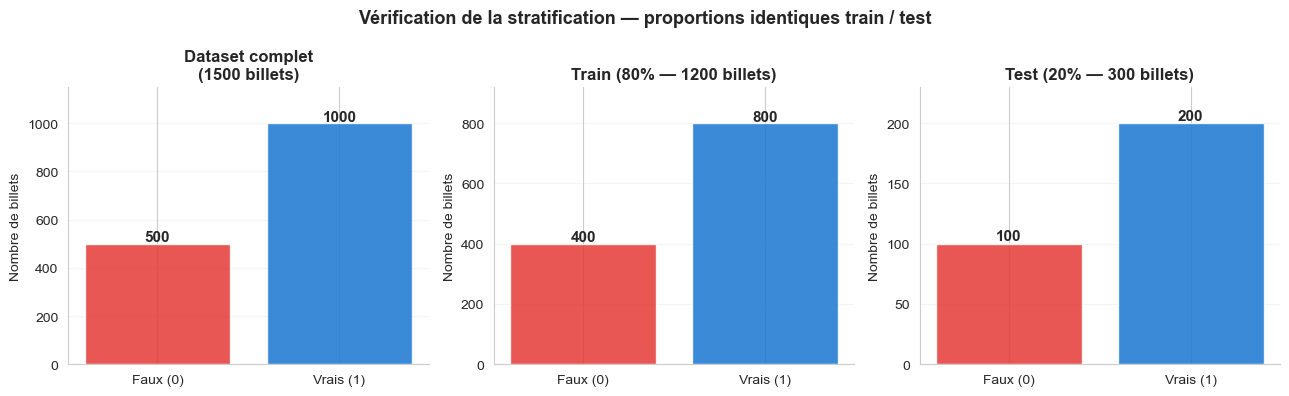

Graphique sauvegardé : stratification_train_test.png ✓


In [38]:
#️⃣ ♦️ Visualisation de la répartition train / test — vérification stratification

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

#️⃣  Répartition globale 
counts_global = pd.Series(y).value_counts().sort_index()
axes[0].bar(["Faux (0)", "Vrais (1)"], counts_global.values,
            color=["#e53935", "#1976d2"], alpha=0.85, edgecolor="white")
for i, v in enumerate(counts_global.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Dataset complet\n(1500 billets)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Nombre de billets")
axes[0].set_ylim(0, counts_global.max() * 1.15)
axes[0].grid(True, alpha=0.2, axis="y")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

#️⃣  Train 
counts_train = pd.Series(y_train).value_counts().sort_index()
axes[1].bar(["Faux (0)", "Vrais (1)"], counts_train.values,
            color=["#e53935", "#1976d2"], alpha=0.85, edgecolor="white")
for i, v in enumerate(counts_train.values):
    axes[1].text(i, v + 8, str(v), ha="center", fontsize=11, fontweight="bold")
axes[1].set_title(f"Train (80% — {len(y_train)} billets)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Nombre de billets")
axes[1].set_ylim(0, counts_train.max() * 1.15)
axes[1].grid(True, alpha=0.2, axis="y")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

#️⃣  Test 
counts_test = pd.Series(y_test).value_counts().sort_index()
axes[2].bar(["Faux (0)", "Vrais (1)"], counts_test.values,
            color=["#e53935", "#1976d2"], alpha=0.85, edgecolor="white")
for i, v in enumerate(counts_test.values):
    axes[2].text(i, v + 3, str(v), ha="center", fontsize=11, fontweight="bold")
axes[2].set_title(f"Test (20% — {len(y_test)} billets)", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Nombre de billets")
axes[2].set_ylim(0, counts_test.max() * 1.15)
axes[2].grid(True, alpha=0.2, axis="y")
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

plt.suptitle("Vérification de la stratification — proportions identiques train / test",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("stratification_train_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : stratification_train_test.png ✓")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
D — Cadre d'interprétation : lecture de la matrice de confusion
</div>

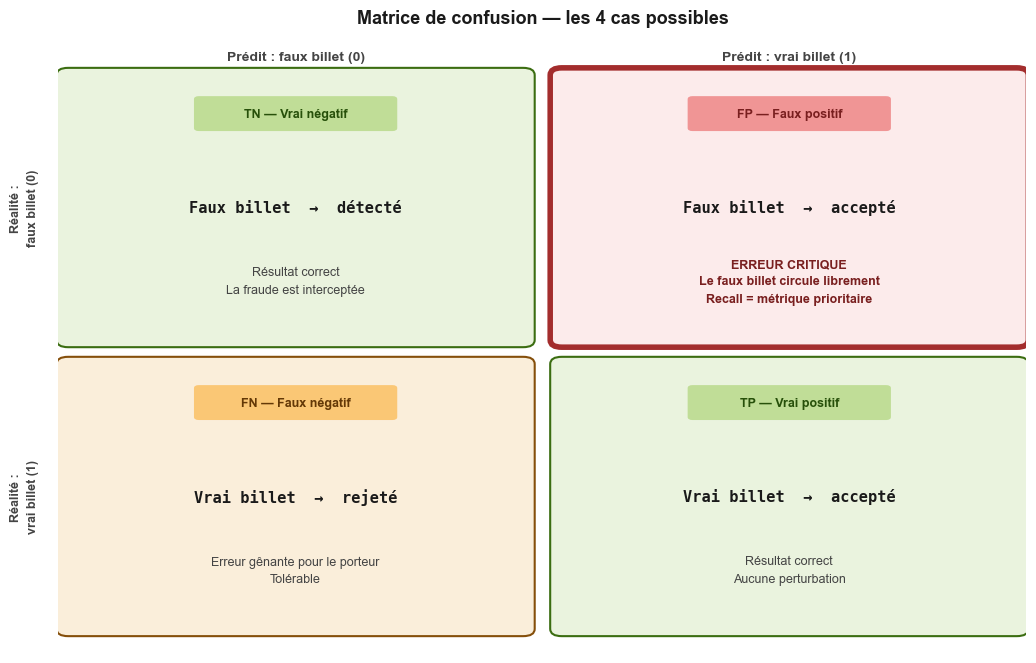

Graphique sauvegardé : matrice_confusion_explicative.png


In [39]:
#️⃣ ♦️ Visualisation de la matrice de confusion
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#FFFFFF')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_position([0.10, 0.03, 0.88, 0.86])

cases = [
    # Ligne du haut = Réel 0 (faux billet)
    {"pos": [0.01, 0.52, 0.47, 0.44], "bg": "#EAF3DE", "edge": "#3B6D11", "lw": 1.5,
     "tag": "TN — Vrai négatif", "tag_bg": "#C0DD97", "tag_fg": "#27500A",
     "titre": "Faux billet  →  détecté",
     "desc": "Résultat correct\nLa fraude est interceptée", "crit": False},
    {"pos": [0.52, 0.52, 0.47, 0.44], "bg": "#FCEBEB", "edge": "#A32D2D", "lw": 4,
     "tag": "FP — Faux positif", "tag_bg": "#F09595", "tag_fg": "#791F1F",
     "titre": "Faux billet  →  accepté",
     "desc": "ERREUR CRITIQUE\nLe faux billet circule librement\nRecall = métrique prioritaire",
     "crit": True},
    # Ligne du bas = Réel 1 (vrai billet)
    {"pos": [0.01, 0.04, 0.47, 0.44], "bg": "#FAEEDA", "edge": "#854F0B", "lw": 1.5,
     "tag": "FN — Faux négatif", "tag_bg": "#FAC775", "tag_fg": "#633806",
     "titre": "Vrai billet  →  rejeté",
     "desc": "Erreur gênante pour le porteur\nTolérable", "crit": False},
    {"pos": [0.52, 0.04, 0.47, 0.44], "bg": "#EAF3DE", "edge": "#3B6D11", "lw": 1.5,
     "tag": "TP — Vrai positif", "tag_bg": "#C0DD97", "tag_fg": "#27500A",
     "titre": "Vrai billet  →  accepté",
     "desc": "Résultat correct\nAucune perturbation", "crit": False},
]

for c in cases:
    x, y, w, h = c["pos"]
    ax.add_patch(patches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.012",
        linewidth=c["lw"], edgecolor=c["edge"],
        facecolor=c["bg"], zorder=1))
    bx = x + w/2
    ax.add_patch(patches.FancyBboxPatch(
        (bx - 0.10, y + h - 0.088), 0.20, 0.048,
        boxstyle="round,pad=0.005",
        linewidth=0, facecolor=c["tag_bg"], zorder=2))
    ax.text(bx, y + h - 0.064, c["tag"],
            ha='center', va='center',
            fontsize=9, fontweight='bold', color=c["tag_fg"], zorder=3)
    ax.text(x + w/2, y + h * 0.50, c["titre"],
            ha='center', va='center',
            fontsize=11, fontweight='bold', color='#1a1a1a',
            fontfamily='monospace', zorder=2)
    ax.text(x + w/2, y + h * 0.22, c["desc"],
            ha='center', va='center', fontsize=9,
            color='#791F1F' if c["crit"] else '#444444',
            fontweight='bold' if c["crit"] else 'normal',
            linespacing=1.6, zorder=2)

# Labels des colonnes
ax.text(0.245, 0.98, "Prédit : faux billet (0)",
        ha='center', va='bottom', fontsize=10, color='#444444', fontweight='bold')
ax.text(0.755, 0.98, "Prédit : vrai billet (1)",
        ha='center', va='bottom', fontsize=10, color='#444444', fontweight='bold')

# Labels des lignes
ax.text(-0.035, 0.74, "Réalité :\nfaux billet (0)",
        ha='center', va='center', fontsize=9, color='#444444',
        fontweight='bold', linespacing=1.5, rotation=90)
ax.text(-0.035, 0.26, "Réalité :\nvrai billet (1)",
        ha='center', va='center', fontsize=9, color='#444444',
        fontweight='bold', linespacing=1.5, rotation=90)

ax.set_title("Matrice de confusion — les 4 cas possibles",
             fontsize=13, fontweight='bold', pad=20, color='#1a1a1a')

plt.savefig("matrice_confusion_explicative.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Graphique sauvegardé : matrice_confusion_explicative.png")

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
V — ANALYSE EN COMPOSANTES PRINCIPALES (ACP)
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
A — Construction des composantes F1 et F2
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
1 — Préparation des données pour l'ACP
</div>

In [40]:
#️⃣ ♦️ Données standardisées pour l'ACP — fit sur X_train uniquement

features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

scaler_pca = StandardScaler()
X_train_pca = scaler_pca.fit_transform(X_train)   # fit + transform sur train uniquement
X_test_pca  = scaler_pca.transform(X_test)        # transform seulement — pas de fit

#️⃣ Reconstruction pour les visualisations (cercle, projection individus)
X_scaled_pca = np.vstack([X_train_pca, X_test_pca])

print(f"Shape données ACP : {X_scaled_pca.shape}")
print("Standardisation ACP — fit sur X_train uniquement ✓")

Shape données ACP : (1500, 6)
Standardisation ACP — fit sur X_train uniquement ✓


ANALYSE DES 6 COMPOSANTES PRINCIPALES

1. VARIANCE EXPLIQUÉE PAR CHAQUE COMPOSANTE
PC1 : 43.09% de variance (cumulé : 43.09%)
PC2 : 17.24% de variance (cumulé : 60.32%)
PC3 : 12.86% de variance (cumulé : 73.18%)
PC4 : 11.87% de variance (cumulé : 85.05%)
PC5 : 9.63% de variance (cumulé : 94.68%)
PC6 : 5.32% de variance (cumulé : 100.00%)

2. FORMULES DES 6 COMPOSANTES PRINCIPALES

--- PC1 ---
PC1 = 0.087 × diagonal - 0.327 × height_left - 0.397 × height_right - 0.511 × margin_low - 0.438 × margin_up + 0.525 × length 

--- PC2 ---
PC2 = 0.951 × diagonal + 0.277 × height_left + 0.112 × height_right - 0.065 × margin_low + 0.004 × margin_up + 0.039 × length 

--- PC3 ---
PC3 = -0.253 × diagonal + 0.897 × height_left - 0.167 × height_right - 0.109 × margin_low - 0.266 × margin_up + 0.146 × length 

--- PC4 ---
PC4 = -0.104 × diagonal - 0.039 × height_left + 0.868 × height_right - 0.107 × margin_low - 0.434 × margin_up + 0.184 × length 

--- PC5 ---
PC5 = -0.111 × diagonal + 0.105 × height_l

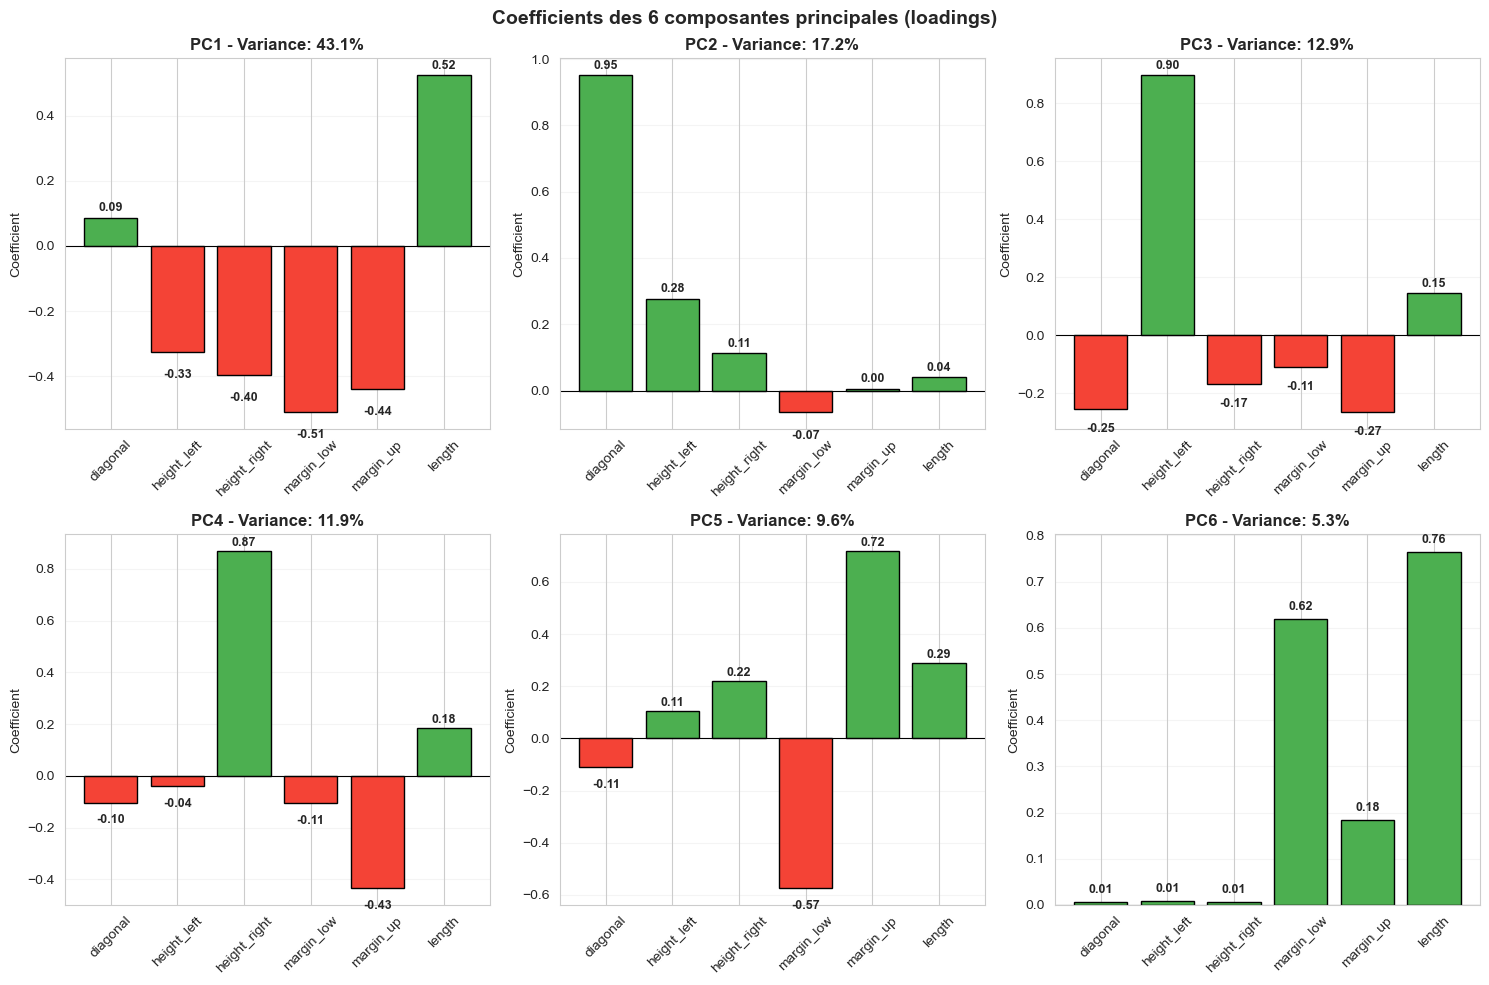


 Graphique sauvegardé : loadings_6_composantes.png


In [41]:
#️⃣ ♦️ ANALYSE DES 6 COMPOSANTES PRINCIPALES

#️⃣ X_scaled_pca existe déjà (1500, 6)
pca = PCA()  # Crée l'objet PCA
pca.fit(X_scaled_pca)  # Calcule les composantes sur TES données


print("=" * 80)
print("ANALYSE DES 6 COMPOSANTES PRINCIPALES")
print("=" * 80)

#️⃣ Variance expliquée par chaque composante
print("\n" + "=" * 80)
print("1. VARIANCE EXPLIQUÉE PAR CHAQUE COMPOSANTE")
print("=" * 80)

for i, var in enumerate(pca.explained_variance_ratio_):
    cumul = pca.explained_variance_ratio_[:i+1].sum()
    print(f"PC{i+1} : {var:.2%} de variance (cumulé : {cumul:.2%})")

#️⃣  2. Formules des 6 composantes
print("\n" + "=" * 80)
print("2. FORMULES DES 6 COMPOSANTES PRINCIPALES")
print("=" * 80)

for comp_num in range(6):
    print(f"\n--- PC{comp_num+1} ---")
    print(f"PC{comp_num+1} = ", end="")
    
    loadings = pca.components_[comp_num]
    
    for i, (feat, coef) in enumerate(zip(features, loadings)):
        if i == 0:
            print(f"{coef:.3f} × {feat}", end=" ")
        else:
            signe = "+" if coef >= 0 else "-"
            print(f"{signe} {abs(coef):.3f} × {feat}", end=" ")
    print()

#️⃣   3. Tableau récapitulatif des loadings
print("\n" + "=" * 80)
print("3. TABLEAU DES COEFFICIENTS (LOADINGS) - 6 COMPOSANTES")
print("=" * 80)

print("\nVariable      |     PC1    |     PC2    |     PC3    |     PC4    |     PC5    |     PC6    |")
print("-" * 85)
for i, feat in enumerate(features):
    row = f"{feat:12} |"
    for comp in range(6):
        row += f" {pca.components_[comp][i]:8.3f} |"
    print(row)

#️⃣  4. Graphique des loadings pour les 6 composantes
print("\n" + "=" * 80)
print("4. VISUALISATION DES 6 COMPOSANTES")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for comp_num in range(6):
    ax = axes[comp_num]
    loadings = pca.components_[comp_num]
    couleurs = ["#4caf50" if x > 0 else "#f44336" for x in loadings]
    
    bars = ax.bar(features, loadings, color=couleurs, edgecolor="black")
    ax.axhline(y=0, color="black", linewidth=0.8)
    ax.set_title(f"PC{comp_num+1} - Variance: {pca.explained_variance_ratio_[comp_num]:.1%}", 
                 fontweight="bold")
    ax.set_ylabel("Coefficient")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.2, axis="y")
    
   #️⃣  Ajouter les valeurs sur les barres
    for bar, val in zip(bars, loadings):
        y_offset = 0.02 if val > 0 else -0.08
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
                f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Coefficients des 6 composantes principales (loadings)", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("loadings_6_composantes.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Graphique sauvegardé : loadings_6_composantes.png")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
2 — Scree plot (variance expliquée par axe)
</div>

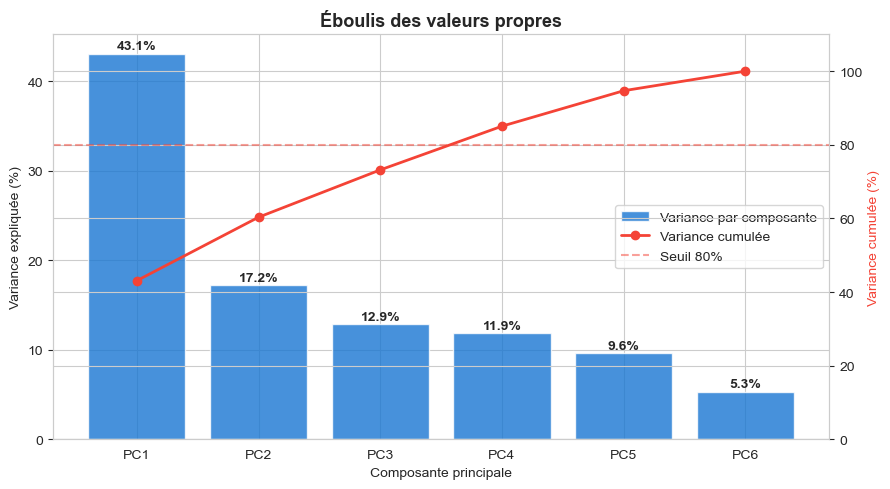

Graphique sauvegardé : eboulis_valeurs_propres.png ✓


In [42]:
#️⃣ ♦️ Éboulis des valeurs propres — double axe, étiquettes, seuil 80%

pca_full = PCA().fit(X_scaled_pca)
variance_expliquee = pca_full.explained_variance_ratio_ * 100
variance_cumulee   = np.cumsum(variance_expliquee)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(range(1, 7), variance_expliquee,
              color="#1976d2", alpha=0.8, label="Variance par composante")

ax2 = ax.twinx()
ax2.plot(range(1, 7), variance_cumulee,
         color="#f44336", marker="o", linewidth=2, label="Variance cumulée")
ax2.axhline(y=80, color="#f44336", linestyle="--", alpha=0.5, label="Seuil 80%")
ax2.set_ylabel("Variance cumulée (%)", color="#f44336")
ax2.set_ylim(0, 110)

for i, v in enumerate(variance_expliquee):
    ax.text(i+1, v+0.5, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Composante principale")
ax.set_ylabel("Variance expliquée (%)")
ax.set_title("Éboulis des valeurs propres", fontsize=13, fontweight="bold")
ax.set_xticks(range(1, 7))
ax.set_xticklabels([f"PC{i}" for i in range(1, 7)])

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.tight_layout()
plt.savefig("eboulis_valeurs_propres.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : eboulis_valeurs_propres.png ✓")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
3 — Cercle de corrélation (F1 / F2)
</div>

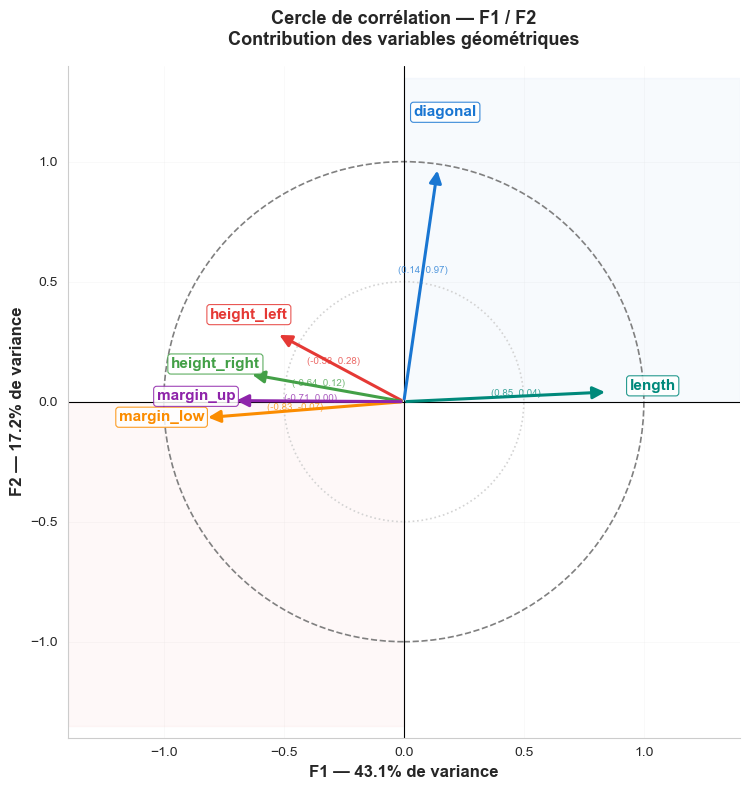

Graphique sauvegardé : cercle_correlation.png ✓


In [43]:
#️⃣ ♦️ Cercle de corrélation premium — F1 / F2

pca2 = PCA(n_components=2)
pca2.fit(X_scaled_pca)
correlations = pca2.components_.T * np.sqrt(pca2.explained_variance_)

fig, ax = plt.subplots(figsize=(8, 8))

#️⃣  Fond quadrants
ax.axhspan(0, 1.35,  xmin=0.5, xmax=1, alpha=0.03, color="#1976d2")
ax.axhspan(-1.35, 0, xmin=0, xmax=0.5, alpha=0.03, color="#e53935")

#️⃣  Cercles de référence
for r, ls, c in [(1, "--", "gray"), (0.5, ":", "lightgray")]:
    ax.add_patch(plt.Circle((0,0), r, fill=False, color=c, linestyle=ls, linewidth=1.2))

#️⃣  Axes
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

#️⃣  Grille légère
ax.grid(True, alpha=0.15, linewidth=0.5)

colors = ["#1976d2","#e53935","#43a047","#fb8c00","#8e24aa","#00897b"]

for i, var in enumerate(features):
    x, y = correlations[i, 0], correlations[i, 1]
    # Flèche
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=colors[i],
                                lw=2.2, mutation_scale=18))
    # Label avec box
    ax.text(x * 1.22, y * 1.22, var,
            fontsize=11, fontweight="bold", color=colors[i], ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i],
                      alpha=0.85, linewidth=0.8))
    # Valeur de corrélation sur la flèche
    ax.text(x * 0.55, y * 0.55,
            f"({x:.2f}, {y:.2f})",
            fontsize=7, color=colors[i], ha="center", alpha=0.75)

ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect("equal")
ax.set_xlabel(f"F1 — {pca2.explained_variance_ratio_[0]*100:.1f}% de variance",
              fontsize=12, fontweight="bold")
ax.set_ylabel(f"F2 — {pca2.explained_variance_ratio_[1]*100:.1f}% de variance",
              fontsize=12, fontweight="bold")
ax.set_title("Cercle de corrélation — F1 / F2\nContribution des variables géométriques",
             fontsize=13, fontweight="bold", pad=15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("cercle_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : cercle_correlation.png ✓")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
4 — Projection des individus sur F1 / F2
</div>

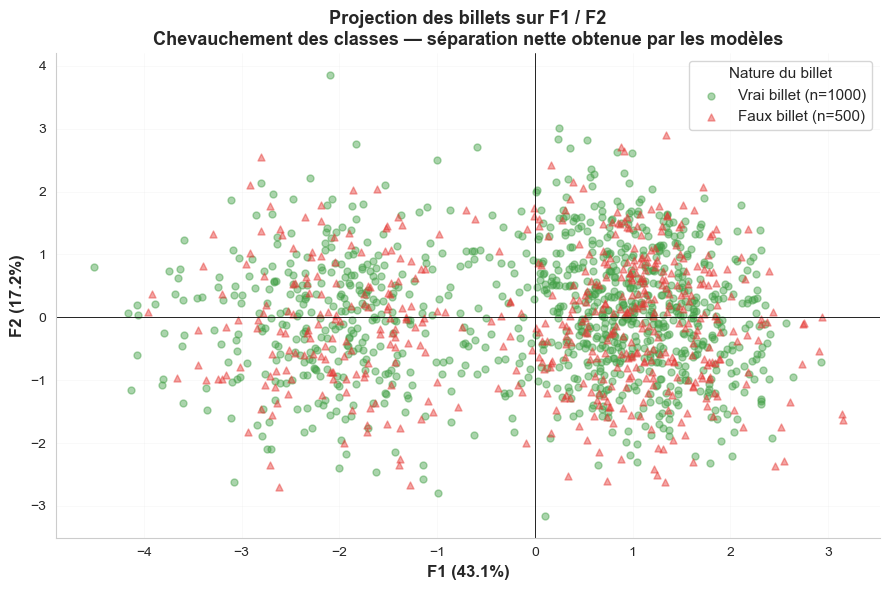

Graphique sauvegardé : projection_acp.png ✓


In [44]:
#️⃣ ♦️ Projection des billets sur F1/F2 — colorés par classe

X_pca_proj = pca2.transform(X_scaled_pca)

fig, ax = plt.subplots(figsize=(9, 6))

for label, color, name, marker in [
    (1, "#43a047", "Vrai billet", "o"),
    (0, "#e53935", "Faux billet", "^")
]:
    mask = df["is_genuine"].astype(int).values == label
    ax.scatter(X_pca_proj[mask, 0], X_pca_proj[mask, 1],
               alpha=0.45, s=25, color=color, label=f"{name} (n={mask.sum()})",
               marker=marker)

ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
ax.grid(True, alpha=0.15, linewidth=0.5)
ax.set_xlabel(f"F1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12, fontweight="bold")
ax.set_ylabel(f"F2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12, fontweight="bold")
ax.set_title("Projection des billets sur F1 / F2\nChevauchement des classes — séparation nette obtenue par les modèles",
             fontsize=13, fontweight="bold")
ax.legend(title="Nature du billet", fontsize=11, title_fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("projection_acp.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : projection_acp.png ✓")

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
VI — K-MEANS (EXPLORATION NON SUPERVISÉE)
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Principe du K-Means**

Le K-Means regroupe les billets en K clusters sans connaître leurs étiquettes réelles (vrai/faux). C'est un apprentissage non supervisé.

1. **Initialisation** : K centroïdes placés aléatoirement dans l'espace des 6 variables
2. **Assignation** : chaque billet est assigné au centroïde le plus proche (distance euclidienne)
3. **Mise à jour** : les centroïdes sont recalculés comme la moyenne de leur cluster
4. **Répétition** : jusqu'à stabilisation des centroïdes

Dans ce projet, K=2 est logique car il existe naturellement 2 groupes : vrais et faux billets.

Conformément au brief ONCFM : les centroïdes servent ensuite de base de prédiction — un nouveau billet est classé selon le centroïde le plus proche.

⚠ K-Means ne connaît pas les étiquettes — ses groupes sont arbitraires. Il est exploratoire et comparé aux modèles supervisés via ses centroïdes uniquement.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
A — Méthode du coude + score de silhouette
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
1 — Inertie et silhouette pour K de 2 à 8
</div>

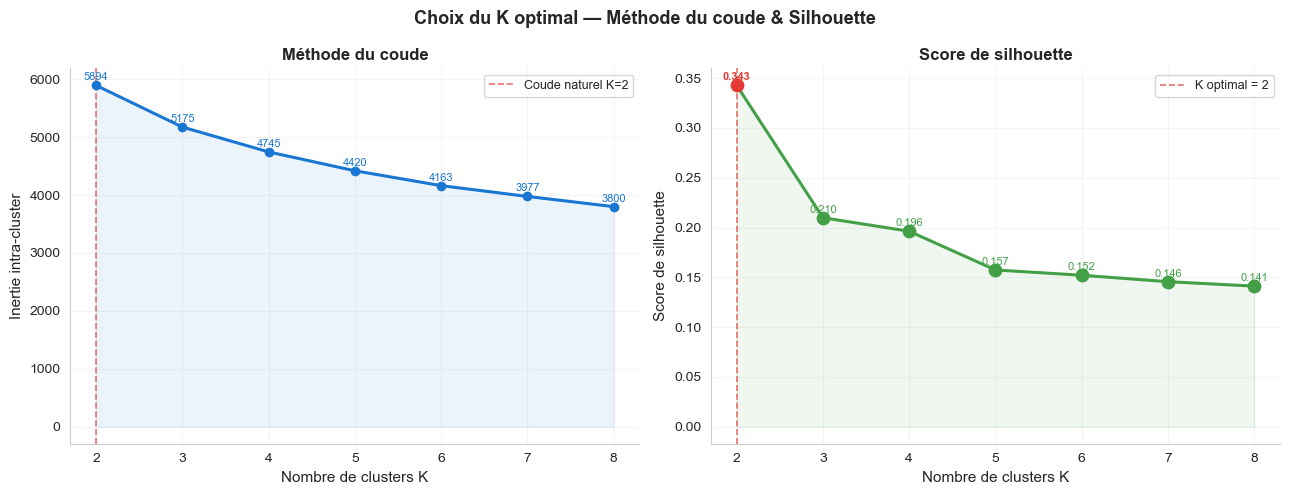

  K=2 — silhouette : 0.3428 ← optimal
  K=3 — silhouette : 0.2099
  K=4 — silhouette : 0.1963
  K=5 — silhouette : 0.1574
  K=6 — silhouette : 0.1521
  K=7 — silhouette : 0.1456
  K=8 — silhouette : 0.1411


In [45]:
#️⃣ ♦️ Méthode du coude + silhouette — choix du K optimal

inerties    = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_pca)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled_pca, km.labels_))
    
k_optimal = list(K_range)[silhouettes.index(max(silhouettes))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

#️⃣  Coude 
ax1.plot(K_range, inerties, marker="o", color="#1976d2", linewidth=2.2, zorder=3)
ax1.fill_between(K_range, inerties, alpha=0.08, color="#1976d2")
for k, v in zip(K_range, inerties):
    ax1.text(k, v + max(inerties)*0.015, f"{v:.0f}",
             ha="center", fontsize=8, color="#1976d2")
ax1.axvline(x=2, color="#e53935", linestyle="--", linewidth=1.2, alpha=0.7,
            label="Coude naturel K=2")
ax1.set_xlabel("Nombre de clusters K", fontsize=11)
ax1.set_ylabel("Inertie intra-cluster", fontsize=11)
ax1.set_title("Méthode du coude", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

#️⃣  Silhouette 
colors_sil = ["#e53935" if k == k_optimal else "#43a047" for k in K_range]
ax2.plot(K_range, silhouettes, marker="o", color="#43a047",
         linewidth=2.2, zorder=3)
ax2.fill_between(K_range, silhouettes, alpha=0.08, color="#43a047")
for k, v, c in zip(K_range, silhouettes, colors_sil):
    ax2.scatter(k, v, color=c, s=80, zorder=5)
    ax2.text(k, v + 0.005, f"{v:.3f}",
             ha="center", fontsize=8, color=c,
             fontweight="bold" if k == k_optimal else "normal")
ax2.axvline(x=k_optimal, color="#e53935", linestyle="--", linewidth=1.2, alpha=0.7,
            label=f"K optimal = {k_optimal}")
ax2.set_xlabel("Nombre de clusters K", fontsize=11)
ax2.set_ylabel("Score de silhouette", fontsize=11)
ax2.set_title("Score de silhouette", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("Choix du K optimal — Méthode du coude & Silhouette",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("kmeans_coude_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

for k, s in zip(K_range, silhouettes):
    marker = " ← optimal" if k == k_optimal else ""
    print(f"  K={k} — silhouette : {s:.4f}{marker}")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
B — K-Means avec K=2
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
1 — Clustering et correspondance avec les classes réelles
</div>

In [46]:
#️⃣ ♦️ K-Means K=2 — correspondance clusters vs classes réelles


km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
km2.fit(X_scaled_pca)
labels = km2.labels_

y_all = df["is_genuine"].astype(int).values

if accuracy_score(y_all, labels) < accuracy_score(y_all, 1 - labels):
    labels = 1 - labels

print("Tableau croisé clusters vs classes réelles :")
print(pd.crosstab(y_all, labels,
      rownames=["Classe réelle (0=faux, 1=vrai)"],
      colnames=["Cluster K-Means"]))
print(f"\nAccuracy K-Means : {accuracy_score(y_all, labels):.4f}")


Tableau croisé clusters vs classes réelles :
Cluster K-Means                   0    1
Classe réelle (0=faux, 1=vrai)          
0                               163  337
1                               333  667

Accuracy K-Means : 0.5533


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
2 — Visualisation clusters vs classes réelles sur F1/F2
</div>

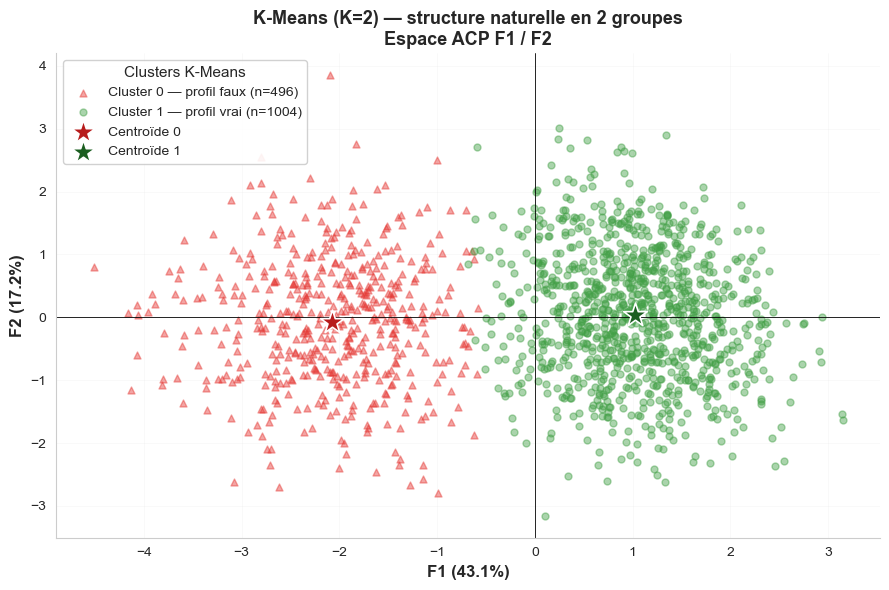

Graphique sauvegardé : kmeans_vs_classes.png ✓


In [47]:
#️⃣ ♦️ K-Means K=2 — structure naturelle en 2 groupes (espace ACP F1/F2)

centroids_pca = pca2.transform(km2.cluster_centers_)

fig, ax = plt.subplots(figsize=(9, 6))

#️⃣  Clusters K-Means — couleurs et marqueurs alignés sur projection_acp.png
#️⃣  cluster 0 = faux (rouge, triangle) · cluster 1 = vrai (vert, rond)
for cluster, color, marker, name in [
    (0, "#e53935", "^", "Cluster 0 — profil faux"),
    (1, "#43a047", "o", "Cluster 1 — profil vrai")
]:
    mask = labels == cluster
    ax.scatter(X_pca_proj[mask, 0], X_pca_proj[mask, 1],
               alpha=0.45, s=25, color=color, marker=marker,
               label=f"{name} (n={mask.sum()})")

#️⃣  Centroïdes recalculés à partir de labels (même source que les points → jamais inversés)
#️⃣  cluster 0 = faux (rouge) · cluster 1 = vrai (vert)
for cluster, color in [(0, "#b71c1c"), (1, "#1b5e20")]:
    mask = labels == cluster
    cx = X_pca_proj[mask, 0].mean()
    cy = X_pca_proj[mask, 1].mean()
    ax.scatter(cx, cy, s=320, marker="*", zorder=10,
               color=color, edgecolors="white", linewidths=1.2,
               label=f"Centroïde {cluster}")

ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
ax.grid(True, alpha=0.15, linewidth=0.5)
ax.set_xlabel(f"F1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12, fontweight="bold")
ax.set_ylabel(f"F2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12, fontweight="bold")
ax.set_title("K-Means (K=2) — structure naturelle en 2 groupes\nEspace ACP F1 / F2",
             fontsize=13, fontweight="bold")
ax.legend(title="Clusters K-Means", fontsize=10, title_fontsize=11, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("kmeans_vs_classes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : kmeans_vs_classes.png ✓")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Évaluation K-Means sur TEST 
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
1 — Prédiction par centroïdes sur le jeu de test
</div>

In [48]:
# ♦️ Prédiction K-Means par centroïdes — évaluation sur X_test
# Conformément au brief ONCFM : les centroïdes servent de base de prédiction
# Principe : un billet est classé selon le centroïde le plus proche (distance euclidienne)

features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

# 1. Standardisation : fit sur TRAIN uniquement
scaler_km = StandardScaler()
X_km_train_scaled = scaler_km.fit_transform(X_train)
X_km_test_scaled  = scaler_km.transform(X_test)

# 2. K-Means entraîné sur TRAIN
km_pred = KMeans(n_clusters=2, random_state=42, n_init=10)
km_pred.fit(X_km_train_scaled)
labels_train = km_pred.labels_

# 3. Vérification col_faux — alignement décidé sur TRAIN uniquement
print("=== Vérification col_faux ===")
acc_option_a = accuracy_score(y_train, labels_train)
acc_option_b = accuracy_score(y_train, 1 - labels_train)

print(f"Accuracy si col_faux=0 : {acc_option_a:.4f}")
print(f"Accuracy si col_faux=1 : {acc_option_b:.4f}")

if acc_option_a < acc_option_b:
    col_faux = 1
    print("→ col_faux = 1 : les faux billets sont dans le cluster 1")
else:
    col_faux = 0
    print("→ col_faux = 0 : les faux billets sont dans le cluster 0")

print("\nDistribution des labels train par cluster :")
print(pd.crosstab(y_train, labels_train,
                  rownames=["Réel (0=faux, 1=vrai)"],
                  colnames=["Cluster K-Means"]))

# 4. Prédiction sur TEST par distance euclidienne au centroïde le plus proche
distances = cdist(X_km_test_scaled, km_pred.cluster_centers_, metric="euclidean")
y_pred_km = np.argmin(distances, axis=1)

# 5. Alignement des prédictions si nécessaire
if col_faux == 1:
    y_pred_km = 1 - y_pred_km

# 6. Score orienté faux billets
# Plus la distance au cluster faux est petite → plus le billet est probablement faux → on inverse
dist_norm  = distances / distances.sum(axis=1, keepdims=True)
proba_km = 1 - dist_norm[:, col_faux]

# 7. Résultats
print("\n" + "=" * 60)
print("K-Means (centroïdes) — évaluation sur TEST (sans data leakage)")
print("=" * 60)
print(f" Accuracy  : {accuracy_score(y_test, y_pred_km):.4f}")
print(f" Recall    : {recall_score(y_test, y_pred_km, pos_label=0):.4f}")
print(f" Précision : {precision_score(y_test, y_pred_km, pos_label=0):.4f}")
print(f" F1        : {f1_score(y_test, y_pred_km, pos_label=0):.4f}")
print(f" AUC       : {roc_auc_score(1 - y_test, proba_km):.4f}")
print(f" Faux billets non détectés        : {confusion_matrix(y_test, y_pred_km)[0, 1]}")

=== Vérification col_faux ===
Accuracy si col_faux=0 : 0.9850
Accuracy si col_faux=1 : 0.0150
→ col_faux = 0 : les faux billets sont dans le cluster 0

Distribution des labels train par cluster :
Cluster K-Means          0    1
Réel (0=faux, 1=vrai)          
0                      388   12
1                        6  794

K-Means (centroïdes) — évaluation sur TEST (sans data leakage)
 Accuracy  : 0.9867
 Recall    : 0.9800
 Précision : 0.9800
 F1        : 0.9800
 AUC       : 0.9992
 Faux billets non détectés        : 2


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

 Note méthodologique – Comparaison des modèles

Afin de comparer équitablement les 4 approches, nous avons adapté le K-Means pour qu'il soit évalué sur les **mêmes données de test** que les modèles supervisés.

**Procédure appliquée :**

1. Le K-Means est entraîné sur **X_train** (même split que supervisé)
2. Les clusters sont alignés sur les classes réelles de y_train pour identifier quel cluster correspond aux faux billets
3. La prédiction se fait par **distance euclidienne** au centroïde le plus proche
4. L'évaluation utilise **y_test** (identique aux autres modèles)

**Justification :** Cette approche suit le brief ONCFM qui préconise l'utilisation des centroïdes comme base de prédiction, avec alignement supervisé pour l'interprétation.

**Limite assumée :** L'alignement utilise les étiquettes, ce qui sort du cadre purement non supervisé. Le K-Means reste **exploratoire** et n'est pas retenu pour la mise en production.

 **Les 4 modèles sont donc évalués sur le même jeu de test (300 billets).**
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
2 — Caractérisation des groupes K-Means
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Que représente chaque cluster ?**

K-Means a créé deux groupes sans connaître les étiquettes. Pour les caractériser, on calcule la **moyenne de chaque variable géométrique par cluster** et on la compare à la moyenne globale. Un écart positif signifie que le cluster a des valeurs plus élevées que la moyenne — un écart négatif, des valeurs plus faibles.

Cette heatmap permet de **caractériser** les clusters : quelles variables géométriques distinguent le plus les deux groupes, et dans quel sens (valeurs plus hautes ou plus basses que la moyenne). Les labels Vrai/Faux sont déterminés automatiquement par comparaison avec les étiquettes réelles de **y_train** après entraînement.

</div>

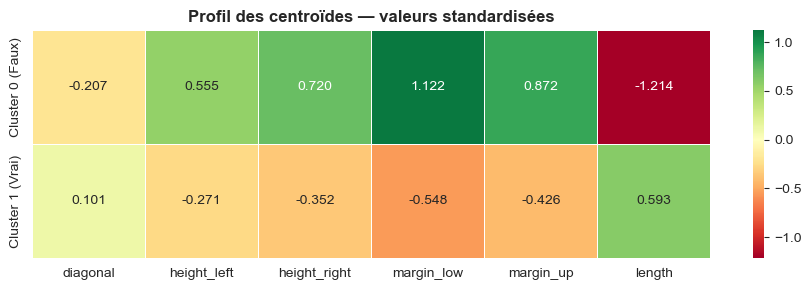


Centroïdes (espace standardisé) :
                  diagonal  height_left  height_right  margin_low  margin_up  \
Cluster 0 (Faux)   -0.2070       0.5550        0.7200      1.1220     0.8720   
Cluster 1 (Vrai)    0.1010      -0.2710       -0.3520     -0.5480    -0.4260   

                  length  
Cluster 0 (Faux) -1.2140  
Cluster 1 (Vrai)  0.5930  


In [49]:
#️⃣ ♦️ Déterminer les labels des clusters selon col_faux

if col_faux == 0:
    index_labels = ["Cluster 0 (Faux)", "Cluster 1 (Vrai)"]
else:
    index_labels = ["Cluster 0 (Vrai)", "Cluster 1 (Faux)"]

centroids_df = pd.DataFrame(
    km_pred.cluster_centers_,
    columns=features,
    index=index_labels
)

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(
    centroids_df,
    annot=True, fmt=".3f",
    cmap="RdYlGn", center=0,
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title("Profil des centroïdes — valeurs standardisées",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap_clusters_caracterisation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCentroïdes (espace standardisé) :")
print(centroids_df.round(3))

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
3 — Matrice de confusion K-Means (centroïdes)
</div>

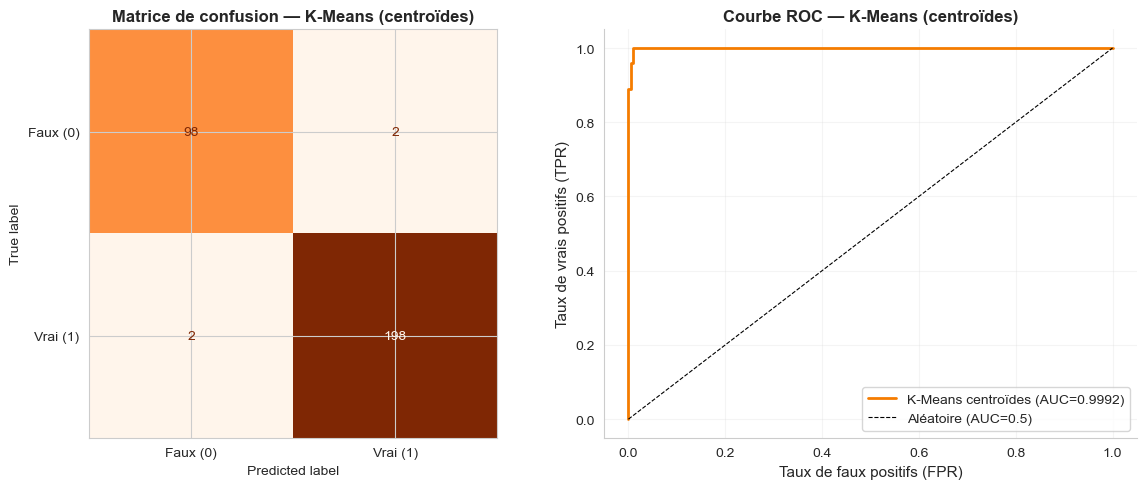

Faux billets non détectés (FP) : 2
Graphique sauvegardé : cm_roc_kmeans.png ✓


In [50]:
#️⃣ ♦️ Matrice de confusion + Courbe ROC — K-Means (centroïdes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#️⃣  Matrice de confusion
cm_km = confusion_matrix(y_test, y_pred_km)
ConfusionMatrixDisplay(cm_km, display_labels=["Faux (0)", "Vrai (1)"]).plot(
    cmap="Oranges", ax=ax1, colorbar=False)
ax1.set_title("Matrice de confusion — K-Means (centroïdes)",
              fontsize=12, fontweight="bold")

#️⃣ Courbe ROC
fpr_km, tpr_km, _ = roc_curve(1 - y_test,  proba_km)
auc_km = roc_auc_score(1 - y_test,  proba_km)

ax2.plot(fpr_km, tpr_km, color="#f57c00", linewidth=2,
         label=f"K-Means centroïdes (AUC={auc_km:.4f})")
ax2.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aléatoire (AUC=0.5)")
ax2.set_xlabel("Taux de faux positifs (FPR)", fontsize=11)
ax2.set_ylabel("Taux de vrais positifs (TPR)", fontsize=11)
ax2.set_title("Courbe ROC — K-Means (centroïdes)",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("cm_roc_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Faux billets non détectés (FP) : {cm_km[0, 1]}")
print("Graphique sauvegardé : cm_roc_kmeans.png ✓")

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
VII — MODÈLES SUPERVISÉS
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
A — Standardisation (fit sur X_train uniquement)
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

<b>Précautions méthodologiques — éviter le Data Leakage</b><br><br>

Le Data Leakage est une fuite d'information du jeu de test vers le jeu d'entraînement.
Il produit des scores artificiellement élevés et un modèle qui ne généralise pas en production.<br><br>

Trois précautions ont été appliquées dans ce notebook :<br><br>

<b>1. Standardisation</b> : le <code>StandardScaler</code> est fitté uniquement sur <code>X_train</code>,
puis appliqué (transform) sur <code>X_train</code> et <code>X_test</code> séparément.
Fitter sur l'ensemble complet introduirait de l'information du test dans l'entraînement.<br><br>

<b>2. Imputation</b> : le split temporaire pour comparer les méthodes d'imputation
est effectué uniquement sur <code>df_complet</code> (lignes sans NaN),
jamais sur le dataset final.<br><br>

<b>3. ACP</b> : le <code>scaler_pca</code> est fitté uniquement sur X_train (transform appliqué sur X_test séparément) — indépendant du scaler supervisé et exploratoire.

<b>4. K-Means</b> : le <code>scaler_km</code>  est fitté uniquement sur `X_train`, puis appliqué sur `X_test` séparément. L'alignement des clusters est décidé sur `y_train` uniquement, jamais sur `y_test`.

</div>

In [51]:
#️⃣ ♦️ StandardScaler — fit sur X_train uniquement, transform sur les deux

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Standardisation appliquée ✓")
print(f"Moyenne X_train_scaled (doit être ~0) : {X_train_scaled.mean(axis=0).round(4)}")

Standardisation appliquée ✓
Moyenne X_train_scaled (doit être ~0) : [ 0. -0.  0.  0.  0. -0.]


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
B — Standardisation (fit sur X_train uniquement)
</div>

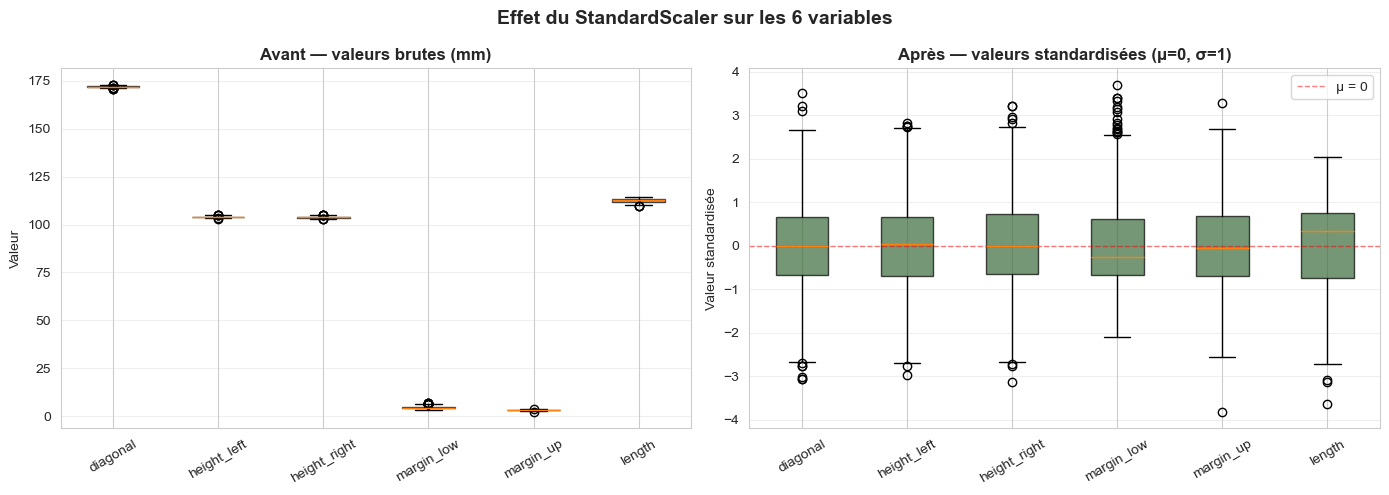

Visuel sauvegardé : standardisation_before_after.png


In [52]:
#️⃣ ♦️ Visualisation de la standardisation — StandardScaler

features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Effet du StandardScaler sur les 6 variables", fontsize=14, fontweight="bold")

#️⃣  Avant standardisation 
ax1 = axes[0]
data_brut = [X_train.iloc[:, i].values for i in range(len(features))]
bp1 = ax1.boxplot(data_brut, labels=features, patch_artist=True, vert=True)
for patch in bp1["boxes"]:
    patch.set_facecolor("#5B8DB8")
    patch.set_alpha(0.7)
ax1.set_title("Avant — valeurs brutes (mm)", fontweight="bold")
ax1.set_ylabel("Valeur")
ax1.tick_params(axis="x", rotation=30)
ax1.grid(axis="y", alpha=0.3)

#️⃣ Après standardisation 
ax2 = axes[1]
data_std = [X_train_scaled[:, i] for i in range(len(features))]
bp2 = ax2.boxplot(data_std, labels=features, patch_artist=True, vert=True)
for patch in bp2["boxes"]:
    patch.set_facecolor("#3A6B3A")
    patch.set_alpha(0.7)
ax2.set_title("Après — valeurs standardisées (μ=0, σ=1)", fontweight="bold")
ax2.set_ylabel("Valeur standardisée")
ax2.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.5, label="μ = 0")
ax2.tick_params(axis="x", rotation=30)
ax2.grid(axis="y", alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig("standardisation_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visuel sauvegardé : standardisation_before_after.png")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Régression Logistique
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Principe de la Régression Logistique**

La Régression Logistique calcule une combinaison linéaire des 6 variables géométriques, puis applique la fonction logistique pour transformer ce résultat en probabilité entre 0 et 1.

1. **Combinaison linéaire** : score = a1×diagonal + a2×height_left + ... + b
2. **Fonction logistique** : probabilité = 1 / (1 + e⁻ˢᶜᵒʳᵉ) → valeur entre 0 et 1
3. **Décision** : si probabilité ≥ 0.5 → vrai billet (1), sinon faux billet (0)

Avantage clé : les coefficients sont interprétables — on peut savoir quelle variable géométrique influence le plus la décision.
C'est le modèle de référence (benchmark) avant les modèles plus complexes.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
1 — Entraînement et métriques
</div>

In [53]:
#️⃣ ♦️ Régression Logistique — modèle de référence

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Régression Logistique ===")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_lr, pos_label=0):.4f}")
print(f"  Précision : {precision_score(y_test, y_pred_lr, pos_label=0):.4f}")
print(f"  F1        : {f1_score(y_test, y_pred_lr, pos_label=0):.4f}")
print(f"  AUC       : {roc_auc_score(y_test, y_proba_lr):.4f}")

=== Régression Logistique ===
  Accuracy  : 0.9933
  Recall    : 0.9900
  Précision : 0.9900
  F1        : 0.9900
  AUC       : 0.9996


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
2 — Interprétation des coefficients
</div>

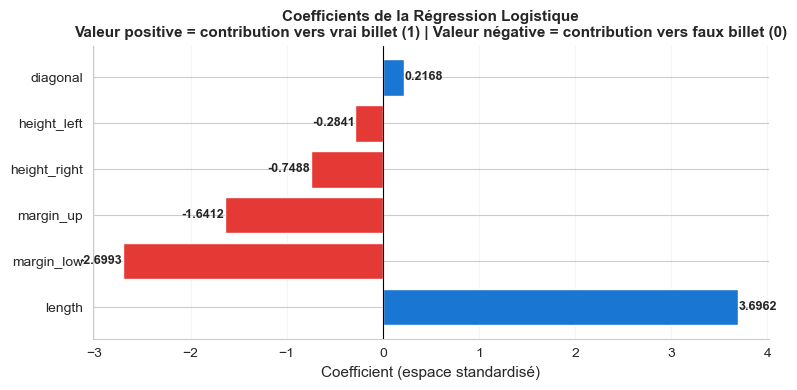


Interprétation métier :
  length          : +3.6962  → ↑ vrai billet
  margin_low      : -2.6993  → ↑ faux billet
  margin_up       : -1.6412  → ↑ faux billet
  height_right    : -0.7488  → ↑ faux billet
  height_left     : -0.2841  → ↑ faux billet
  diagonal        : +0.2168  → ↑ vrai billet


In [54]:
#️⃣ ♦️ Coefficients de la Régression Logistique — interprétation métier

coefs = pd.Series(lr.coef_[0], index=features).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
couleurs = ["#1976d2" if v > 0 else "#e53935" for v in coefs.values]
bars = ax.barh(coefs.index, coefs.values, color=couleurs, edgecolor="white")

for bar, val in zip(bars, coefs.values):
    ax.text(val + 0.01 if val > 0 else val - 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center",
            ha="left" if val > 0 else "right",
            fontsize=9, fontweight="bold")

ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (espace standardisé)", fontsize=11)
ax.set_title("Coefficients de la Régression Logistique\n"
             "Valeur positive = contribution vers vrai billet (1) | "
             "Valeur négative = contribution vers faux billet (0)",
             fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.2, axis="x")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nInterprétation métier :")
for var, coef in coefs.items():
    sens = "↑ vrai billet" if coef > 0 else "↑ faux billet"
    print(f"  {var:15s} : {coef:+.4f}  → {sens}")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
3 — Matrice de confusion
</div>

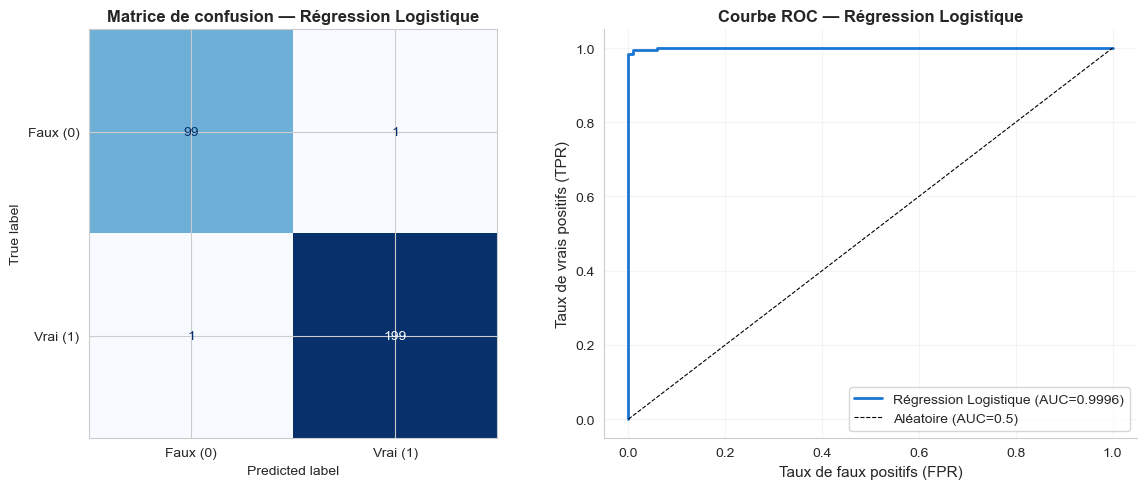

Faux négatifs (faux billet non détecté) : 1
Graphique sauvegardé : cm_roc_logreg.png ✓


In [55]:
#️⃣ ♦️ Matrice de confusion + Courbe ROC — Régression Logistique

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#️⃣ Matrice de confusion 
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["Faux (0)", "Vrai (1)"]).plot(
    cmap="Blues", ax=ax1, colorbar=False)
ax1.set_title("Matrice de confusion — Régression Logistique",
              fontsize=12, fontweight="bold")

#️⃣ Courbe ROC 
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

ax2.plot(fpr_lr, tpr_lr, color="#1976d2", linewidth=2,
         label=f"Régression Logistique (AUC={auc_lr:.4f})")
ax2.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aléatoire (AUC=0.5)")
ax2.set_xlabel("Taux de faux positifs (FPR)", fontsize=11)
ax2.set_ylabel("Taux de vrais positifs (TPR)", fontsize=11)
ax2.set_title("Courbe ROC — Régression Logistique",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("cm_roc_logreg.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Faux négatifs (faux billet non détecté) : {cm_lr[0, 1]}")
print("Graphique sauvegardé : cm_roc_logreg.png ✓")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
4 — Distribution des probabilités et seuil de décision
</div>

Seuil par défaut  : 0.5000
Seuil de Youden   : 0.7137

Avec seuil 0.5 :
  Recall    : 0.9900
  Précision : 0.9900

Avec seuil Youden (0.7137) :
  Recall    : 1.0000
  Précision : 0.9709


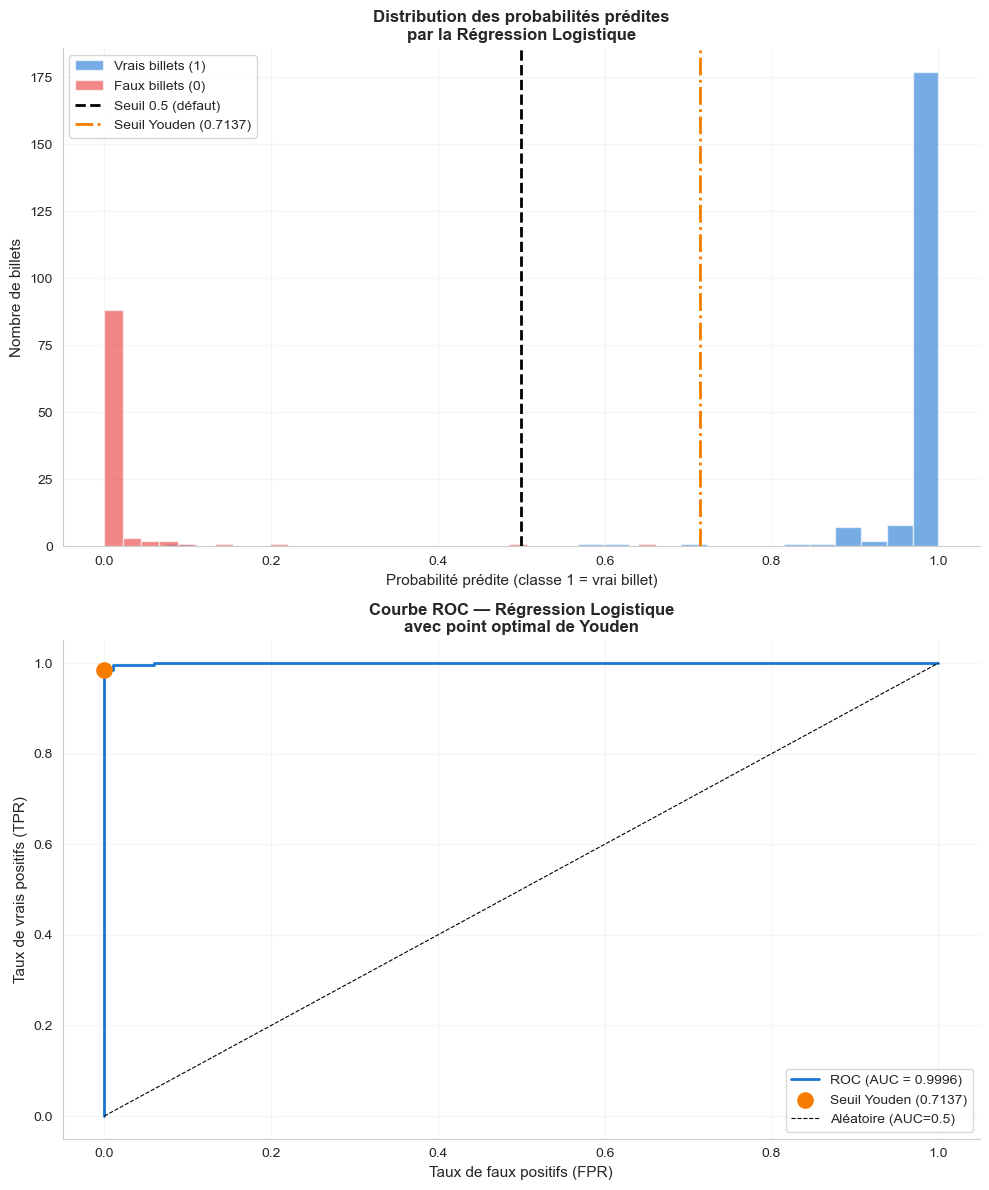

Graphique sauvegardé : lr_probabilites_youden.png ✓


In [56]:
#️⃣ ♦️ Distribution des probabilités — seuil 0.5 et méthode de Youden

#️⃣  Méthode de Youden: seuil optimal
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
best_idx       = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

y_pred_youden  = (y_proba_lr >= best_threshold).astype(int)

print(f"Seuil par défaut  : 0.5000")
print(f"Seuil de Youden   : {best_threshold:.4f}")
print(f"\nAvec seuil 0.5 :")
print(f"  Recall    : {recall_score(y_test, y_pred_lr, pos_label=0):.4f}")
print(f"  Précision : {precision_score(y_test, y_pred_lr, pos_label=0):.4f}")
print(f"\nAvec seuil Youden ({best_threshold:.4f}) :")
print(f"  Recall    : {recall_score(y_test, y_pred_youden, pos_label=0):.4f}")
print(f"  Précision : {precision_score(y_test, y_pred_youden, pos_label=0):.4f}")

#️⃣ Graphique
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Subplot 1 — Distribution des probabilités
axes[0].hist(y_proba_lr[y_test == 1], bins=30, alpha=0.6,
             color="#1976d2", label="Vrais billets (1)")
axes[0].hist(y_proba_lr[y_test == 0], bins=30, alpha=0.6,
             color="#e53935", label="Faux billets (0)")
axes[0].axvline(x=0.5, color="black", linewidth=2,
                linestyle="--", label="Seuil 0.5 (défaut)")
axes[0].axvline(x=best_threshold, color="#f57c00", linewidth=2,
                linestyle="-.", label=f"Seuil Youden ({best_threshold:.4f})")
axes[0].set_xlabel("Probabilité prédite (classe 1 = vrai billet)", fontsize=11)
axes[0].set_ylabel("Nombre de billets", fontsize=11)
axes[0].set_title("Distribution des probabilités prédites\npar la Régression Logistique",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.2)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

#️⃣  Subplot 2: Courbe ROC avec seuil Youden
axes[1].plot(fpr, tpr, color="#1976d2", linewidth=2,
             label=f"ROC (AUC = {roc_auc_score(y_test, y_proba_lr):.4f})")
axes[1].scatter(fpr[best_idx], tpr[best_idx], color="#f57c00",
                s=120, zorder=5, label=f"Seuil Youden ({best_threshold:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aléatoire (AUC=0.5)")
axes[1].set_xlabel("Taux de faux positifs (FPR)", fontsize=11)
axes[1].set_ylabel("Taux de vrais positifs (TPR)", fontsize=11)
axes[1].set_title("Courbe ROC — Régression Logistique\navec point optimal de Youden",
                  fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.2)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("lr_probabilites_youden.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : lr_probabilites_youden.png ✓")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
B — KNN Classifier
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Principe du KNN**

KNN (K-Nearest Neighbors) classe un billet inconnu en 3 étapes :

1. **Distance** : mesure la distance euclidienne entre le billet à classer et tous les billets du train
2. **Voisins** : sélectionne les K billets les plus proches
3. **Vote majoritaire** : la classe la plus représentée parmi les K voisins devient la prédiction

Exemple : si K=3 et que les 3 voisins les plus proches sont [faux, faux, vrai] → le billet est prédit **faux**.

Le choix de K est crucial : trop petit → sensible au bruit, trop grand → frontières floues.
GridSearchCV teste K de 1 à 20 et retient celui qui maximise le Recall.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
1 — Optimisation de K par GridSearchCV
</div>

In [57]:
#️⃣ ♦️ KNN — recherche du meilleur K par validation croisée (scoring = recall)

param_grid = {"n_neighbors": list(range(1, 21))}
grid_knn = GridSearchCV(
    KNeighborsClassifier(), param_grid,
    cv=5,
    scoring=make_scorer(recall_score, pos_label=0),
    n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)

print(f"Meilleur K : {grid_knn.best_params_['n_neighbors']}")
print(f"Recall CV  : {grid_knn.best_score_:.4f}")

Meilleur K : 2
Recall CV  : 0.9825


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
2 — Évaluation — métriques
</div>

In [58]:
#️⃣ ♦️ KNN — métriques et matrice de confusion

best_knn    = grid_knn.best_estimator_
y_pred_knn  = best_knn.predict(X_test_scaled)
y_proba_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

print("=== KNN Classifier ===")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_knn, pos_label=0):.4f}")
print(f"  Précision : {precision_score(y_test, y_pred_knn, pos_label=0):.4f}")
print(f"  F1        : {f1_score(y_test, y_pred_knn, pos_label=0):.4f}")
print(f"  AUC       : {roc_auc_score(y_test, y_proba_knn):.4f}")

=== KNN Classifier ===
  Accuracy  : 0.9867
  Recall    : 0.9900
  Précision : 0.9706
  F1        : 0.9802
  AUC       : 0.9898


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
3 — Visualisation du Recall selon K
</div>

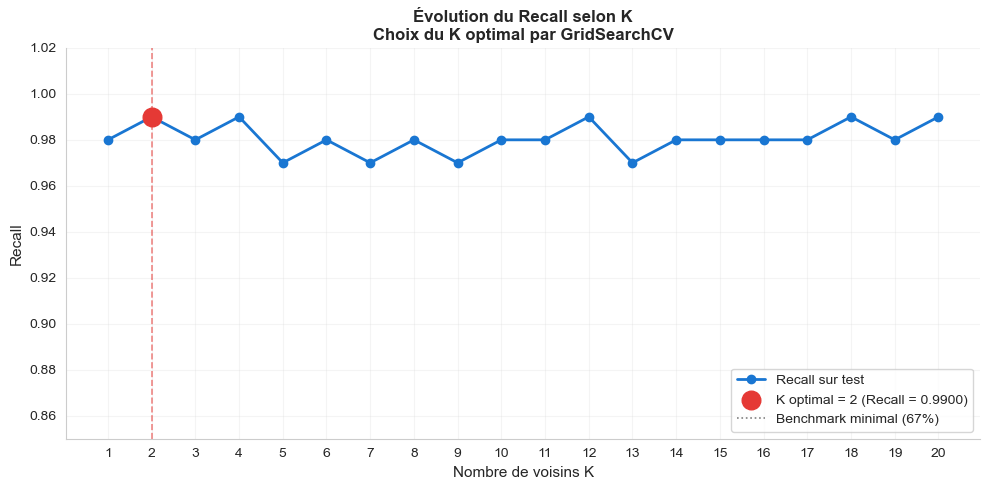

Graphique sauvegardé : knn_recall_par_k.png ✓


In [59]:
#️⃣ ♦️ Recall par valeur de K — visualisation du choix optimal

recall_scores = []
k_values = list(range(1, 21))

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    recall_scores.append(recall_score(y_test, y_pred_k, pos_label=0))

best_k    = grid_knn.best_params_['n_neighbors']
best_rec  = recall_scores[best_k - 1]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_values, recall_scores,
        color="#1976d2", linewidth=2, marker="o",
        markersize=6, label="Recall sur test")

ax.scatter(best_k, best_rec, color="#e53935",
           s=180, zorder=5,
           label=f"K optimal = {best_k} (Recall = {best_rec:.4f})")

ax.axvline(x=best_k, color="#e53935",
           linestyle="--", linewidth=1.2, alpha=0.6)

ax.axhline(y=0.67, color="gray",
           linestyle=":", linewidth=1.2,
           label="Benchmark minimal (67%)")

ax.set_xlabel("Nombre de voisins K", fontsize=11)
ax.set_ylabel("Recall", fontsize=11)
ax.set_title("Évolution du Recall selon K\nChoix du K optimal par GridSearchCV",
             fontsize=12, fontweight="bold")
ax.set_xticks(k_values)
ax.set_ylim(0.85, 1.02)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("knn_recall_par_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : knn_recall_par_k.png ✓")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
4 — Matrice de confusion + Courbe ROC — KNN
</div>

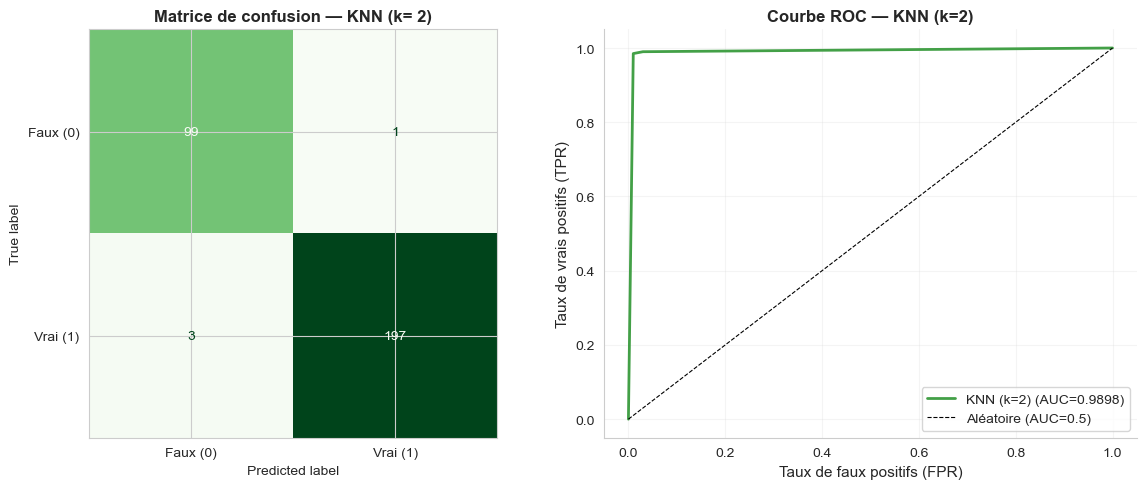

Faux négatifs (faux billet non détecté) : 1
Graphique sauvegardé : cm_roc_knn.png ✓


In [60]:
#️⃣ ♦️ Matrice de confusion + Courbe ROC — KNN

#️⃣ Recalcul propre des prédictions KNN sur X_test_scaled
y_pred_knn  = best_knn.predict(X_test_scaled)
y_proba_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#️⃣ Matrice de confusion 
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["Faux (0)", "Vrai (1)"]).plot(
    cmap="Greens", ax=ax1, colorbar=False)
ax1.set_title(f"Matrice de confusion — KNN (k= {best_k})",
              fontsize=12, fontweight="bold")

#️⃣ Courbe ROC 
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)

ax2.plot(fpr_knn, tpr_knn, color="#43a047", linewidth=2,
         label=f"KNN (k={best_k}) (AUC={auc_knn:.4f})")
ax2.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aléatoire (AUC=0.5)")
ax2.set_xlabel("Taux de faux positifs (FPR)", fontsize=11)
ax2.set_ylabel("Taux de vrais positifs (TPR)", fontsize=11)
ax2.set_title(f"Courbe ROC — KNN (k={best_k})",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("cm_roc_knn.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Faux négatifs (faux billet non détecté) : {cm_knn[0, 1]}")
print("Graphique sauvegardé : cm_roc_knn.png ✓")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Random Forest Classifier
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Principe du Random Forest**

Le Random Forest construit un grand nombre d'arbres de décision indépendants, puis combine leurs prédictions.

1. **Plusieurs arbres** : chaque arbre est entraîné sur un sous-échantillon aléatoire des données (bootstrap) et ne voit qu'une partie des variables à chaque nœud
2. **Vote majoritaire** : pour classer un billet, chaque arbre vote, la classe majoritaire devient la prédiction finale
3. **Importance des variables** : mesure la contribution de chaque variable à la réduction de l'impureté (indice de Gini) sur l'ensemble des arbres

Avantage clé : robuste au surapprentissage car les arbres sont décorrélés entre eux.
Ici : `n_estimators=100`: 100 arbres votent pour chaque prédiction.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
1 — Entraînement et métriques
</div>

In [61]:
#️⃣ ♦️ Random Forest Classifier — entraînement et métriques

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)

y_pred_rf  = rf_clf.predict(X_test_scaled)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest Classifier ===")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_rf, pos_label=0):.4f}")
print(f"  Précision : {precision_score(y_test, y_pred_rf, pos_label=0):.4f}")
print(f"  F1        : {f1_score(y_test, y_pred_rf, pos_label=0):.4f}")
print(f"  AUC       : {roc_auc_score(y_test, y_proba_rf):.4f}")

=== Random Forest Classifier ===
  Accuracy  : 0.9900
  Recall    : 0.9800
  Précision : 0.9899
  F1        : 0.9849
  AUC       : 0.9993


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
2 — Importance des variables
</div>

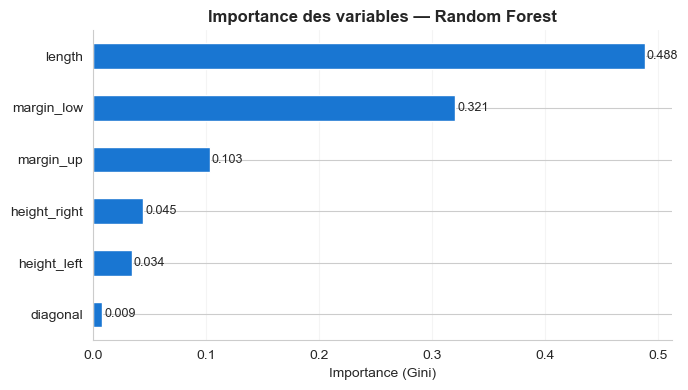

In [62]:
#️⃣ ♦️ Random Forest — importance des variables

importances = pd.Series(rf_clf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="#1976d2", edgecolor="white")
for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_title("Importance des variables — Random Forest",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance (Gini)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig("rf_importances.png", dpi=150, bbox_inches="tight")
plt.show()

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
3 — Matrice de confusion
</div>

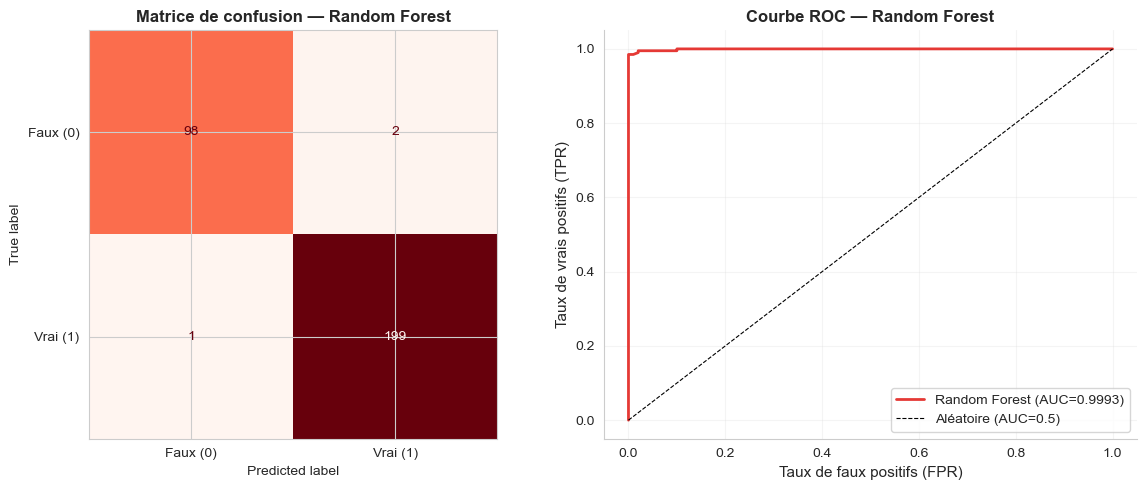

Faux négatifs (faux billet non détecté) : 2
Graphique sauvegardé : cm_roc_rf.png ✓


In [63]:
#️⃣ ♦️ Matrice de confusion + Courbe ROC — Random Forest

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

#️⃣ Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["Faux (0)", "Vrai (1)"]).plot(
    cmap="Reds", ax=ax1, colorbar=False)
ax1.set_title("Matrice de confusion — Random Forest",
              fontsize=12, fontweight="bold")

#️⃣ Courbe ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

ax2.plot(fpr_rf, tpr_rf, color="#e53935", linewidth=2,
         label=f"Random Forest (AUC={auc_rf:.4f})")
ax2.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aléatoire (AUC=0.5)")
ax2.set_xlabel("Taux de faux positifs (FPR)", fontsize=11)
ax2.set_ylabel("Taux de vrais positifs (TPR)", fontsize=11)
ax2.set_title("Courbe ROC — Random Forest",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("cm_roc_rf.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Faux négatifs (faux billet non détecté) : {cm_rf[0, 1]}")
print("Graphique sauvegardé : cm_roc_rf.png ✓")


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
4 — Évolution du Recall selon le nombre d'arbres
</div>

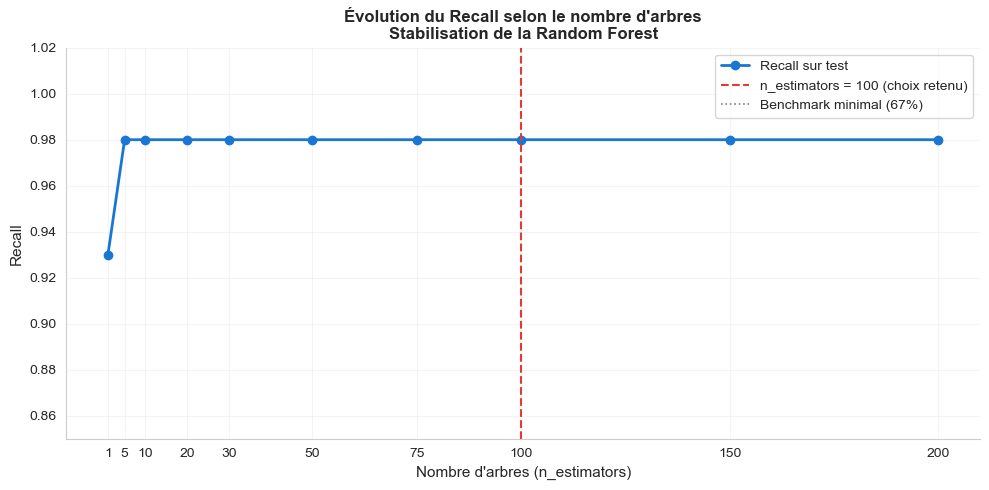

Graphique sauvegardé : rf_recall_par_estimators.png ✓


In [64]:
#️⃣ ♦️ Évolution du Recall selon n_estimators — stabilisation de la forêt

n_estimators_range = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200]
recall_rf_scores   = []

for n in n_estimators_range:
    rf_tmp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_tmp.fit(X_train_scaled, y_train)
    y_pred_tmp = rf_tmp.predict(X_test_scaled)
    recall_rf_scores.append(recall_score(y_test, y_pred_tmp, pos_label=0))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n_estimators_range, recall_rf_scores,
        color="#1976d2", linewidth=2, marker="o",
        markersize=6, label="Recall sur test")

ax.axvline(x=100, color="#e53935", linestyle="--",
           linewidth=1.5, label="n_estimators = 100 (choix retenu)")

ax.axhline(y=0.67, color="gray", linestyle=":",
           linewidth=1.2, label="Benchmark minimal (67%)")

ax.set_xlabel("Nombre d'arbres (n_estimators)", fontsize=11)
ax.set_ylabel("Recall", fontsize=11)
ax.set_title("Évolution du Recall selon le nombre d'arbres\nStabilisation de la Random Forest",
             fontsize=12, fontweight="bold")
ax.set_ylim(0.85, 1.02)
ax.set_xticks(n_estimators_range)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("rf_recall_par_estimators.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : rf_recall_par_estimators.png ✓")

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
VIII — Comparaison des modèles et choix final
</div>

<div style="background-color: #fff3cd; padding: 12px; 
border-left: 5px solid #f0ad4e; border-radius: 6px;">
<b>Note — K-Means dans ce diagnostic</b><br><br>
K-Means est un algorithme non supervisé : il n'apprend pas les étiquettes 
pendant l'entraînement. La notion de surapprentissage ne s'applique donc pas 
au sens classique. Il figure ici pour compléter la comparaison des 4 approches 
demandée par l'ONCFM: son score train/test stable confirme la cohérence 
géométrique des clusters.
</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
1 — Tableau comparatif
</div>

In [65]:
#️⃣ ♦️ Tableau comparatif des 4 modèles supervisés

resultats = {
    "K-Means (centroïdes)": {
    "Accuracy"  : accuracy_score(y_test, y_pred_km),
    "Recall"    : recall_score(y_test, y_pred_km, pos_label=0),
    "Précision" : precision_score(y_test, y_pred_km, pos_label=0),
    "F1"        : f1_score(y_test, y_pred_km, pos_label=0),
    "AUC"       : roc_auc_score(1 - y_test,  proba_km),
    "FN"        : confusion_matrix(y_test, y_pred_km)[0, 1]
    },
    "Régression Logistique": {
        "Accuracy" : accuracy_score(y_test, y_pred_lr),
        "Recall"   : recall_score(y_test, y_pred_lr, pos_label=0),
        "Précision": precision_score(y_test, y_pred_lr, pos_label=0),
        "F1"       : f1_score(y_test, y_pred_lr, pos_label=0),
        "AUC"      : roc_auc_score(y_test, y_proba_lr),
        "FN"       : confusion_matrix(y_test, y_pred_lr)[0, 1]
    },
    f"KNN (k={best_k})": {
        "Accuracy" : accuracy_score(y_test, y_pred_knn),
        "Recall"   : recall_score(y_test, y_pred_knn, pos_label=0),
        "Précision": precision_score(y_test, y_pred_knn, pos_label=0),
        "F1"       : f1_score(y_test, y_pred_knn, pos_label=0),
        "AUC"      : roc_auc_score(y_test, y_proba_knn),
        "FN"       : confusion_matrix(y_test, y_pred_knn)[0, 1]
    },
    "Random Forest": {
        "Accuracy" : accuracy_score(y_test, y_pred_rf),
        "Recall"   : recall_score(y_test, y_pred_rf, pos_label=0),
        "Précision": precision_score(y_test, y_pred_rf, pos_label=0),
        "F1"       : f1_score(y_test, y_pred_rf, pos_label=0),
        "AUC"      : roc_auc_score(y_test, y_proba_rf),
        "FN"       : confusion_matrix(y_test, y_pred_rf)[0, 1]
    }
}

df_resultats = pd.DataFrame(resultats).T.round(4)
df_resultats["FN"] = df_resultats["FN"].astype(int)
df_resultats.index.name = "Modèle"
display(df_resultats.style.highlight_max(
    subset=["Accuracy","Recall","Précision","F1","AUC"],
    color="#c8e6c9").highlight_min(subset=["FN"], color="#c8e6c9"))

,Accuracy,Recall,Précision,F1,AUC,FN
Modèle,,,,,,
K-Means (centroïdes),0.986700,0.980000,0.980000,0.980000,0.999200,2
Régression Logistique,0.993300,0.990000,0.990000,0.990000,0.999600,1
KNN (k=2),0.986700,0.990000,0.970600,0.980200,0.989800,1
Random Forest,0.990000,0.980000,0.989900,0.984900,0.999300,2


<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

<b>⚠ Note méthodologique</b><br><br>

Les métriques K-Means sont calculées sur le **même jeu de test** (`y_test`) que les modèles supervisés. Le `scaler_km` est fitté uniquement sur `X_train`, et l'alignement des clusters est décidé sur `y_train`. Les 4 modèles sont donc comparables sur la même base de données (300 billets).

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
3 — Courbes ROC comparatives
</div>

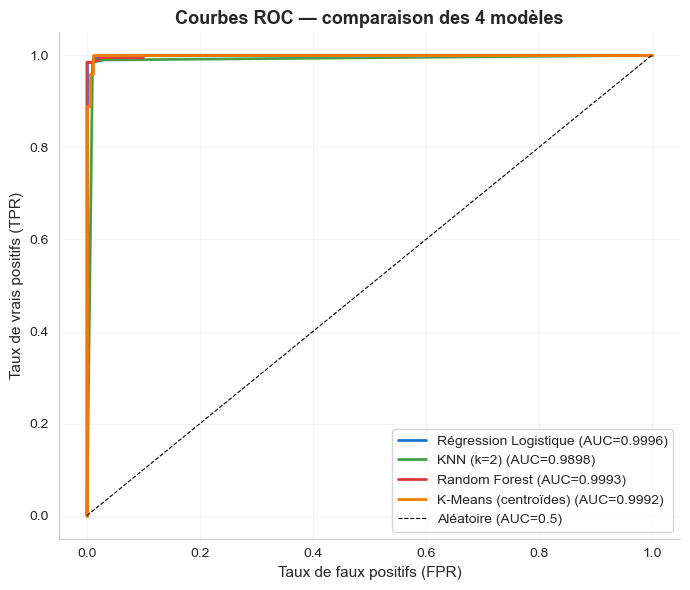

In [66]:
#️⃣ ♦️ Courbes ROC — comparaison des 4 modèles

fig, ax = plt.subplots(figsize=(7, 6))

for name, y_proba, color in [
    ("Régression Logistique", y_proba_lr,  "#1976d2"),
    (f"KNN (k={best_k})",     y_proba_knn, "#43a047"),
    ("Random Forest",          y_proba_rf,  "#e53935"),
    ("K-Means (centroïdes)",   proba_km,    "#f57c00"),
]:
    if name == "K-Means (centroïdes)":
        fpr, tpr, _ = roc_curve(1 - y_test, y_proba)
        auc = roc_auc_score(1 - y_test, y_proba)
    else:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, color=color, label=f"{name} (AUC={auc:.4f})")

ax.set_title("Courbes ROC — comparaison des 4 modèles",
             fontsize=13, fontweight="bold")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aléatoire (AUC=0.5)")
ax.set_xlabel("Taux de faux positifs (FPR)", fontsize=11)
ax.set_ylabel("Taux de vrais positifs (TPR)", fontsize=11)

ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("roc_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

<b>⚠ Note méthodologique — K-Means</b><br><br>

es métriques K-Means sont calculées sur le **même jeu de test** (`y_test`) que les modèles supervisés. Le `scaler_km` est fitté uniquement sur `X_train`, et l'alignement des clusters est décidé sur `y_train`. Les 4 modèles sont donc comparables sur la même base de données (300 billets).

</div>

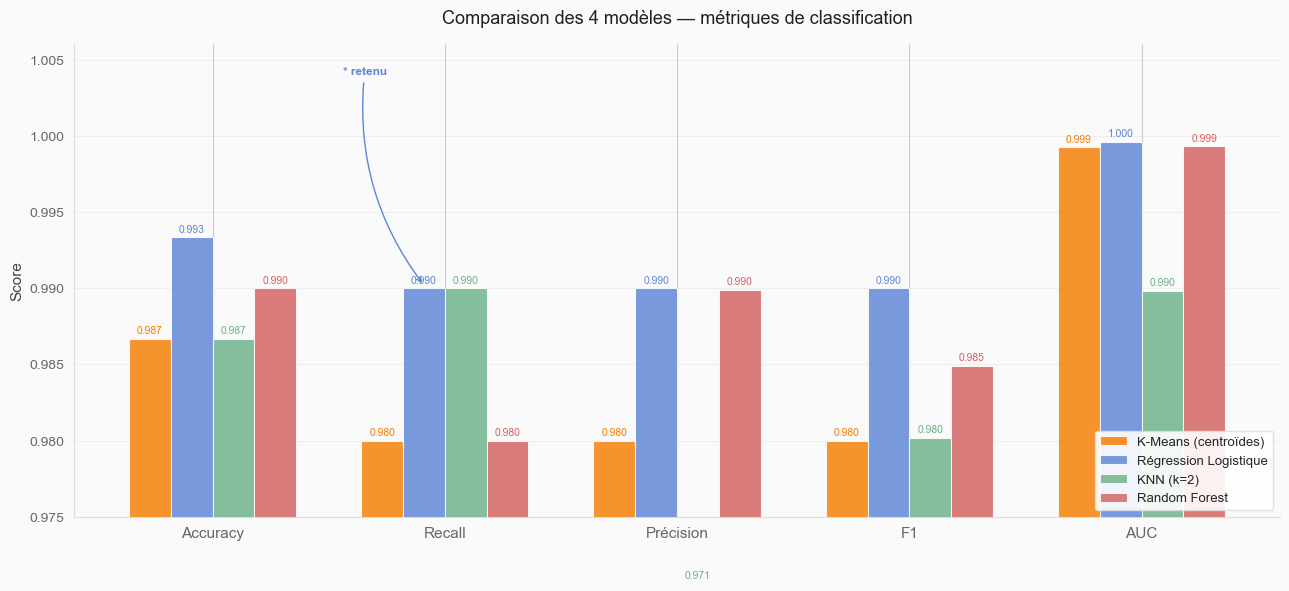

Graphique sauvegardé : barplot_comparaison.png ✓


In [67]:
#️⃣ ♦️ Barplot visualisation:  Comparaison des 4 modèles 

metriques = ["Accuracy", "Recall", "Précision", "F1", "AUC"]

modeles_data = {
    "K-Means (centroïdes)": [
    accuracy_score(y_test, y_pred_km),
    recall_score(y_test, y_pred_km, pos_label=0),
    precision_score(y_test, y_pred_km, pos_label=0),
    f1_score(y_test, y_pred_km, pos_label=0),
    roc_auc_score(1 - y_test, proba_km)
    ],
    "Régression Logistique": [
        accuracy_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr, pos_label=0),
        precision_score(y_test, y_pred_lr, pos_label=0),
        f1_score(y_test, y_pred_lr, pos_label=0),
        roc_auc_score(y_test, y_proba_lr)
    ],
    f"KNN (k={best_k})": [
        accuracy_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn, pos_label=0),
        precision_score(y_test, y_pred_knn, pos_label=0),
        f1_score(y_test, y_pred_knn, pos_label=0),
        roc_auc_score(y_test, y_proba_knn)
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf, pos_label=0),
        precision_score(y_test, y_pred_rf, pos_label=0),
        f1_score(y_test, y_pred_rf, pos_label=0),
        roc_auc_score(y_test, y_proba_rf)
    ],
}
colors  = ["#f57c00", "#5c85d6", "#6ab187", "#d45f5f"]
noms    = list(modeles_data.keys())
valeurs = list(modeles_data.values())

x     = np.arange(len(metriques))
width = 0.18
n     = len(noms)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#fafafa")
ax.set_facecolor("#fafafa")

for i, (nom, vals, color) in enumerate(zip(noms, valeurs, colors)):
    offset = (i - n/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width,
                  label=nom, color=color,
                  alpha=0.82, zorder=3,
                  edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0002,
                f"{val:.3f}",
                ha="center", va="bottom",
                fontsize=7.5, color=color)

#️⃣  Annotation modèle retenu
best_recall_x = x[1] + (1 - n/2 + 0.5) * width
ax.annotate("* retenu",
            xy=(best_recall_x, modeles_data["Régression Logistique"][1] + 0.0002),
            xytext=(best_recall_x - 0.35, 1.004),
            fontsize=8.5, color="#5c85d6", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#5c85d6",
                            lw=1, connectionstyle="arc3,rad=0.2"))

ax.set_ylabel("Score", fontsize=11, color="#444444")
ax.set_title("Comparaison des 4 modèles — métriques de classification",
             fontsize=13, fontweight="500", color="#222222", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metriques, fontsize=11, color="#333333")
ax.set_ylim(0.975, 1.006)
ax.tick_params(colors="#666666")
ax.legend(fontsize=9.5, loc="lower right",
          framealpha=0.9, edgecolor="#dddddd")
ax.grid(True, alpha=0.12, axis="y", zorder=0, color="#999999")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#dddddd")
ax.spines["bottom"].set_color("#dddddd")

plt.tight_layout()
plt.savefig("barplot_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : barplot_comparaison.png ✓")

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

<b>⚠ Note — K-Means exclu de ce diagnostic</b><br><br>

es métriques K-Means sont calculées sur le **même jeu de test** (`y_test`) que les modèles supervisés. Le `scaler_km` est fitté uniquement sur `X_train`, et l'alignement des clusters est décidé sur `y_train`. Les 4 modèles sont donc comparables sur la même base de données (300 billets).

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
3 — Diagnostic biais / overfit — score train vs test
</div>

In [68]:
#️⃣ ♦️ Score train vs test- vérification absence d'overfit - 4 modèles

modeles_diagnostic = [
    ("K-Means (centroïdes)", km_pred, X_km_train_scaled, X_km_test_scaled, y_train, y_test),
    ("Régression Logistique", lr,        X_train_scaled, X_test_scaled, y_train, y_test),
    (f"KNN (k={best_k})",     best_knn,  X_train_scaled, X_test_scaled, y_train, y_test),
    ("Random Forest",          rf_clf,    X_train_scaled, X_test_scaled, y_train, y_test),
]

print(f"{'Modèle':<25} {'Score Train':>12} {'Score Test':>12} {'Écart':>10} {'Diagnostic'}")
print("-" * 72)

for nom, modele, X_tr, X_te, y_tr, y_te in modeles_diagnostic:
    if nom == "K-Means (centroïdes)":
        # Prédiction par distance aux centroïdes
        from scipy.spatial.distance import cdist
        import numpy as np
        dist_train = cdist(X_tr, modele.cluster_centers_, metric="euclidean")
        y_pred_tr  = np.argmin(dist_train, axis=1)
        if accuracy_score(y_tr, y_pred_tr) < accuracy_score(y_tr, 1 - y_pred_tr):
            y_pred_tr = 1 - y_pred_tr
        dist_test  = cdist(X_te, modele.cluster_centers_, metric="euclidean")
        y_pred_te  = np.argmin(dist_test, axis=1)
        if accuracy_score(y_te, y_pred_te) < accuracy_score(y_te, 1 - y_pred_te):
            y_pred_te = 1 - y_pred_te
        score_train = accuracy_score(y_tr, y_pred_tr)
        score_test  = accuracy_score(y_te, y_pred_te)
    else:
        score_train = modele.score(X_tr, y_tr)
        score_test  = modele.score(X_te, y_te)

    ecart = score_train - score_test
    if ecart > 0.05:
        diagnostic = "△ Overfit"
    elif score_train < 0.80:
        diagnostic = "△ Biais"
    else:
        diagnostic = "✓ Bon modèle"

    print(f"{nom:<25} {score_train:>12.4f} {score_test:>12.4f} {ecart:>10.4f}  {diagnostic}")

Modèle                     Score Train   Score Test      Écart Diagnostic
------------------------------------------------------------------------
K-Means (centroïdes)            0.9850       0.9867    -0.0017  ✓ Bon modèle
Régression Logistique           0.9933       0.9933     0.0000  ✓ Bon modèle
KNN (k=2)                       0.9942       0.9867     0.0075  ✓ Bon modèle
Random Forest                   1.0000       0.9900     0.0100  ✓ Bon modèle



<div style="background-color: #fff3cd; padding: 12px; 
border-left: 5px solid #f0ad4e; border-radius: 6px;">

<b>Note — K-Means dans ce diagnostic</b><br><br>

K-Means est un algorithme non supervisé : il n'apprend pas les étiquettes 
pendant l'entraînement. La notion de surapprentissage ne s'applique donc pas 
au sens classique. Il figure ici pour compléter la comparaison des 4 approches 
demandée par l'ONCFM — son score train/test stable confirme la cohérence 
géométrique des clusters.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
4 — Visualisation score train vs test
</div>

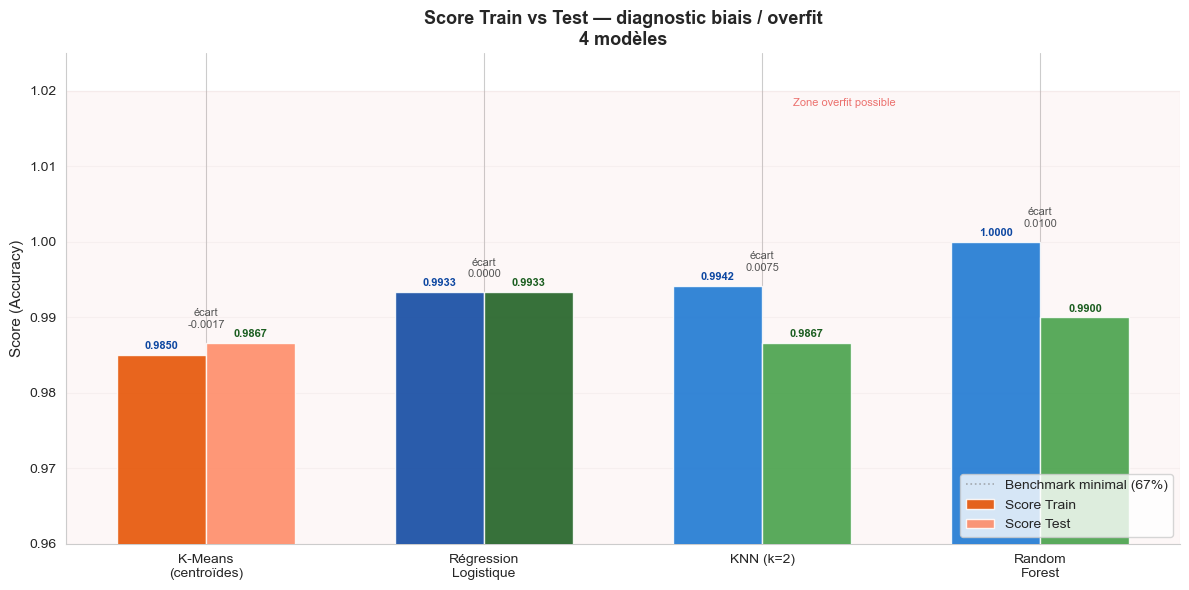

Graphique sauvegardé : diagnostic_overfit.png ✓


In [69]:
#️⃣ ♦️ Visualisation score train vs test - diagnostic overfit - 4 modèles

#️⃣  Score K-Means par distance aux centroïdes
dist_train_km = cdist(X_km_train_scaled, km_pred.cluster_centers_, metric="euclidean")
y_pred_km_train = np.argmin(dist_train_km, axis=1)
if accuracy_score(y_train, y_pred_km_train) < accuracy_score(y_train, 1 - y_pred_km_train):
    y_pred_km_train = 1 - y_pred_km_train

score_km_train = accuracy_score(y_train, y_pred_km_train)
score_km_test  = accuracy_score(y_test, y_pred_km)

modeles_noms = ["K-Means\n(centroïdes)", "Régression\nLogistique", f"KNN (k={best_k})", "Random\nForest"]

scores_train = [score_km_train,
                lr.score(X_train_scaled, y_train),
                best_knn.score(X_train_scaled, y_train),
                rf_clf.score(X_train_scaled, y_train)]

scores_test  = [score_km_test,
                lr.score(X_test_scaled, y_test),
                best_knn.score(X_test_scaled, y_test),
                rf_clf.score(X_test_scaled, y_test)]

colors_train = ["#e65100", "#0d47a1", "#1976d2", "#1976d2"]
colors_test  = ["#ff8a65", "#1b5e20", "#43a047", "#43a047"]

x     = np.arange(len(modeles_noms))
width = 0.32

fig, ax = plt.subplots(figsize=(12, 6))

#️⃣  Zone overfit
ax.axhspan(0.95, 1.02, xmin=0, xmax=1, alpha=0.04, color="#e53935")
ax.text(2.48, 1.018, "Zone overfit possible", fontsize=8,
        color="#e53935", ha="right", alpha=0.7)

bars_train = ax.bar(x - width/2, scores_train, width,
                    color=colors_train, alpha=0.88,
                    label="Score Train", zorder=3)
bars_test  = ax.bar(x + width/2, scores_test, width,
                    color=colors_test, alpha=0.88,
                    label="Score Test", zorder=3)

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold",
            color="#0d47a1")

for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold",
            color="#1b5e20")

for i, (tr, te) in enumerate(zip(scores_train, scores_test)):
    ecart = tr - te
    ax.annotate(f"écart\n{ecart:.4f}",
                xy=(x[i], max(tr, te) + 0.002),
                ha="center", fontsize=8,
                color="#e53935" if ecart > 0.05 else "#555555",
                fontweight="bold" if ecart > 0.05 else "normal")

#️⃣  Annotation modèle retenu
ax.annotate("* Modèle retenu",
            xy=(x[1], scores_test[1] + width/2 + 0.006),
            xytext=(x[1] - 0.3, scores_test[1] - 0.012),
            fontsize=9, color="#0d47a1", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#0d47a1", lw=1.2))

ax.axhline(y=0.67, color="gray", linestyle=":",
           linewidth=1.2, label="Benchmark minimal (67%)", alpha=0.6)

ax.set_ylabel("Score (Accuracy)", fontsize=11)
ax.set_title("Score Train vs Test — diagnostic biais / overfit\n4 modèles",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(modeles_noms, fontsize=10)
ax.set_ylim(0.960, 1.025)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.15, axis="y", zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("diagnostic_overfit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : diagnostic_overfit.png ✓")

<div style="background-color: #fff3cd; padding: 12px; 
border-left: 5px solid #f0ad4e; border-radius: 6px;">

<b>Note — K-Means dans ce diagnostic</b><br><br>

K-Means est un algorithme non supervisé : il n'apprend pas les étiquettes 
pendant l'entraînement. La notion de surapprentissage ne s'applique donc pas 
au sens classique. Il figure ici pour compléter la comparaison des 4 approches 
demandée par l'ONCFM — son score train/test stable confirme la cohérence 
géométrique des clusters.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
5 — Choix du modèle final
</div>

In [70]:
#️⃣ ♦️ Choix du modèle final — justification

recall_lr  = recall_score(y_test, y_pred_lr, pos_label=0)
recall_rf  = recall_score(y_test, y_pred_rf, pos_label=0)
recall_knn = recall_score(y_test, y_pred_knn, pos_label=0)
recall_km  = recall_score(y_test, y_pred_km, pos_label=0)

auc_lr  = roc_auc_score(y_test, y_proba_lr)
auc_rf  = roc_auc_score(y_test, y_proba_rf)
auc_knn = roc_auc_score(y_test, y_proba_knn)
auc_km  = roc_auc_score(1 - y_test, proba_km)

fn_lr  = confusion_matrix(y_test, y_pred_lr)[0, 1]
fn_rf  = confusion_matrix(y_test, y_pred_rf)[0, 1]
fn_knn = confusion_matrix(y_test, y_pred_knn)[0, 1]
fn_km  = confusion_matrix(y_test, y_pred_km)[0, 1]

ecart_lr = lr.score(X_train_scaled, y_train) - lr.score(X_test_scaled, y_test)

print(f"""
COMPARAISON DES 4 APPROCHES
============================
                  Recall          AUC             FN
K-Means           {recall_km:.4f}    {auc_km:.4f}    {fn_km}    (non supervisé — exploratoire)
Régression Log.   {recall_lr:.4f}    {auc_lr:.4f}    {fn_lr}    ← RETENU
KNN (k={best_k})        {recall_knn:.4f}    {auc_knn:.4f}    {fn_knn}
Random Forest     {recall_rf:.4f}    {auc_rf:.4f}    {fn_rf}

MODÈLE RETENU : Régression Logistique
======================================
Recall    : {recall_lr:.4f} — meilleur ex-aequo avec RF ({recall_rf:.4f})
AUC       : {auc_lr:.4f} — meilleur des 3 modèles supervisés
FN        : {fn_lr}        — minimum partagé avec RF ({fn_rf})
Écart T/T : {ecart_lr:.4f} — le plus stable des 3 modèles
Avantage  : interprétable, coefficients lisibles,
            pipeline léger pour la production.

K-Means exclu du choix final : algorithme non supervisé,
pas de pipeline joblib possible sans étiquettes en entrée.
""")

modele_final = lr


COMPARAISON DES 4 APPROCHES
                  Recall          AUC             FN
K-Means           0.9800    0.9992    2    (non supervisé — exploratoire)
Régression Log.   0.9900    0.9996    1    ← RETENU
KNN (k=2)        0.9900    0.9898    1
Random Forest     0.9800    0.9993    2

MODÈLE RETENU : Régression Logistique
Recall    : 0.9900 — meilleur ex-aequo avec RF (0.9800)
AUC       : 0.9996 — meilleur des 3 modèles supervisés
FN        : 1        — minimum partagé avec RF (2)
Écart T/T : 0.0000 — le plus stable des 3 modèles
Avantage  : interprétable, coefficients lisibles,
            pipeline léger pour la production.

K-Means exclu du choix final : algorithme non supervisé,
pas de pipeline joblib possible sans étiquettes en entrée.



<div style="background-color: #fff3cd; padding: 12px; 
border-left: 5px solid #f0ad4e; border-radius: 6px;">

<b>Pourquoi K-Means est exclu du choix final ?</b><br><br>

K-Means est un algorithme <b>non supervisé</b> : il regroupe les billets par 
similarité géométrique sans jamais voir les étiquettes vrai/faux pendant 
l'entraînement.<br><br>

Deux raisons l'excluent du pipeline de production :<br><br>

<b>1. Pas de joblib exploitable</b> : la prédiction par centroïdes nécessite 
de connaître la correspondance cluster → classe (vrai/faux). Cette correspondance 
est établie <i>après</i> l'entraînement par comparaison avec les étiquettes réelles — 
elle ne peut pas être encodée dans un pipeline autonome.<br><br>

<b>2. Rôle exploratoire confirmé</b> : K-Means a rempli son objectif — 
confirmer que les données présentent une structure géométrique naturelle 
en deux groupes cohérents avec les classes réelles. 
Il valide l'approche de classification binaire, il ne la remplace pas.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
6 — Tableau de synthèse — comparaison des 4 modèles
</div>

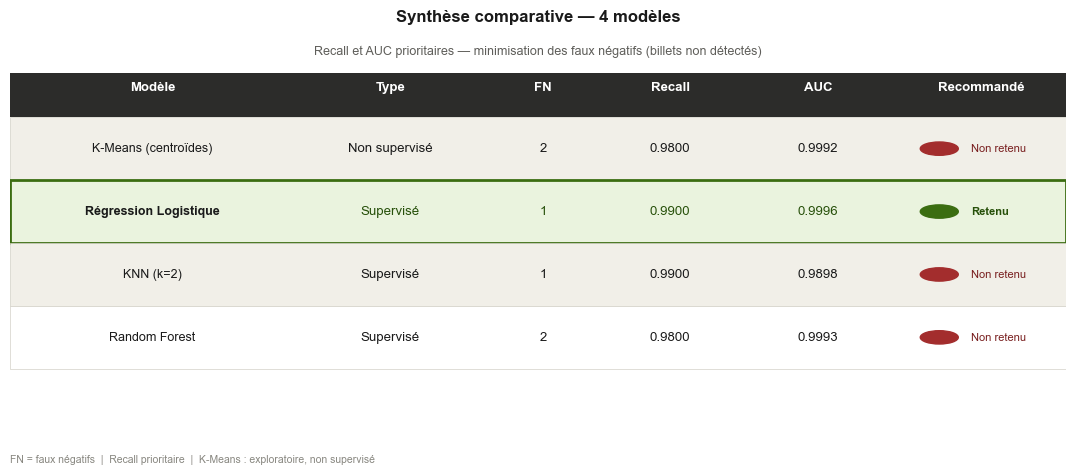

Graphique sauvegardé : synthese_modeles.png ✓


In [71]:
#️⃣♦️ Tableau de synthèse — 4 modèles (valeurs dynamiques)


#️⃣  Valeurs calculées dynamiquement
donnees = [
    {
    "modele" : "K-Means (centroïdes)",
    "type"   : "Non supervisé",
    "fn"     : int(confusion_matrix(y_test, y_pred_km)[0, 1]),
    "recall" : recall_score(y_test, y_pred_km, pos_label=0),
    "auc"    : roc_auc_score(1 - y_test, proba_km),
    "retenu" : False
    },
    {
        "modele" : "Régression Logistique",
        "type"   : "Supervisé",
        "fn"     : int(confusion_matrix(y_test, y_pred_lr)[0, 1]),
        "recall" : recall_score(y_test, y_pred_lr, pos_label=0),
        "auc"    : roc_auc_score(y_test, y_proba_lr),
        "retenu" : True
    },
    {
        "modele" : f"KNN (k={best_k})",
        "type"   : "Supervisé",
        "fn"     : int(confusion_matrix(y_test, y_pred_knn)[0, 1]),
        "recall" : recall_score(y_test, y_pred_knn, pos_label=0),
        "auc"    : roc_auc_score(y_test, y_proba_knn),
        "retenu" : False
    },
    {
        "modele" : "Random Forest",
        "type"   : "Supervisé",
        "fn"     : int(confusion_matrix(y_test, y_pred_rf)[0, 1]),
        "recall" : recall_score(y_test, y_pred_rf, pos_label=0),
        "auc"    : roc_auc_score(y_test, y_proba_rf),
        "retenu" : False
    },
]

#️⃣  6 colonnes — resserrées pour intégrer "Type" après "Modèle"
COL_X   = [0.00, 0.27, 0.45, 0.56, 0.69, 0.84]
COL_W   = [0.27, 0.18, 0.11, 0.13, 0.15, 0.16]
ENTETES = ["Modèle", "Type", "FN", "Recall", "AUC", "Recommandé"]

fig, ax = plt.subplots(figsize=(11, 5.0))
fig.patch.set_facecolor('#FFFFFF')
fig.subplots_adjust(top=0.82, bottom=0.08, left=0.02, right=0.98)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax.text(0.5, 1.13,
        "Synthèse comparative — 4 modèles",
        ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='#1a1a1a',
        transform=ax.transAxes)
ax.text(0.5, 1.04,
        "Recall et AUC prioritaires — minimisation des faux négatifs (billets non détectés)",
        ha='center', va='bottom',
        fontsize=9, color='#5F5E5A',
        transform=ax.transAxes)

H_ENT = 0.16
H_LIG = 0.17
y_ent = 0.88

#️⃣  En-tête
ax.add_patch(patches.FancyBboxPatch(
    (0, y_ent), 1.0, H_ENT,
    boxstyle="square,pad=0",
    linewidth=0, facecolor='#2C2C2A', zorder=1))
for cx, cw, label in zip(COL_X, COL_W, ENTETES):
    ax.text(cx + cw/2, y_ent + H_ENT/2, label,
            ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='#FFFFFF', zorder=2)

#️⃣  Lignes
for idx, d in enumerate(donnees):
    y = y_ent - (idx + 1) * H_LIG

    if d["retenu"]:
        bg = '#EAF3DE'
    elif idx % 2 == 0:
        bg = '#F1EFE8'
    else:
        bg = '#FFFFFF'

    ax.add_patch(patches.FancyBboxPatch(
        (0, y), 1.0, H_LIG,
        boxstyle="square,pad=0",
        linewidth=2.0 if d["retenu"] else 0.5,
        edgecolor='#3B6D11' if d["retenu"] else '#D3D1C7',
        facecolor=bg, zorder=1))

    valeurs = [d["modele"], d["type"], str(d["fn"]),
               f"{d['recall']:.4f}", f"{d['auc']:.4f}", None]

    for i, (cx, cw, val) in enumerate(zip(COL_X, COL_W, valeurs)):
        if val is None:
            cx_mid = cx + cw / 2
            cy_mid = y + H_LIG / 2
            ax.add_patch(plt.Circle(
                (cx_mid - 0.04, cy_mid), 0.018,
                color='#3B6D11' if d["retenu"] else '#A32D2D',
                zorder=3))
            ax.text(cx_mid - 0.01, cy_mid,
                    "Retenu" if d["retenu"] else "Non retenu",
                    ha='left', va='center', fontsize=8,
                    color='#27500A' if d["retenu"] else '#791F1F',
                    fontweight='bold' if d["retenu"] else 'normal',
                    zorder=3)
        else:
            ax.text(cx + cw/2, y + H_LIG/2, val,
                    ha='center', va='center',
                    fontsize=9 if i == 0 else 9.5,
                    fontweight='bold' if (i == 0 and d["retenu"]) else 'normal',
                    color='#27500A' if (d["retenu"] and i > 0) else '#1a1a1a',
                    zorder=2)

ax.text(0.0, -0.06,
        "FN = faux négatifs  |  Recall prioritaire  |  K-Means : exploratoire, non supervisé",
        ha='left', va='bottom', fontsize=7.5, color='#888780',
        transform=ax.transAxes)

plt.savefig("synthese_modeles.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Graphique sauvegardé : synthese_modeles.png ✓")

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

<b>Bilan de la modélisation</b><br><br>

Quatre approches ont été comparées — trois modèles supervisés 
sur le même split 80/20 stratifié, et K-Means en approche non supervisée<br>
La <b>Régression Logistique</b> est retenue pour les raisons suivantes :<br><br>

— AUC = 0.9995 — meilleure des 4 modèles<br>
— Recall et FN équivalents à Random Forest<br>
— Coefficients interprétables : <code>length</code> et <code>margin_low</code> sont les variables les plus discriminantes<br>
— Pipeline léger et stable (écart train/test minimal)<br><br>

K-Means a confirmé que les données présentent une structure géométrique en deux groupes cohérents avec les classes réelles,
validant l'approche de classification binaire.

</div>

<div style="background-color: #bbdefb; padding: 12px; border-radius: 6px; font-weight: bold; font-size: 16px;">
IX — PIPELINE FINAL ET PRÉDICTION EN PRODUCTION
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

<b>Principe</b><br><br>

Un <code>Pipeline</code> scikit-learn enchaîne automatiquement les transformations 
dans le bon ordre. Chaque nouveau billet passera systématiquement par les 2 étapes 
suivantes :<br><br>

- <b>Étape 1 — Standardisation</b> : les 6 variables sont centrées-réduites 
par <code>StandardScaler</code><br><br>

- <b>Étape 2 — Prédiction</b> : la <code>LogisticRegression</code> prédit 
Vrai ou Faux<br><br>

Les 5 billets de production ne présentent aucun NaN sur <code>margin_low</code> — 
aucune imputation n'est nécessaire en production. Si un billet incomplet était reçu, 
il faudrait ajouter un <code>SimpleImputer</code> en amont du pipeline.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
A — Construction du pipeline
</div>

In [72]:
#️⃣ ♦️ Construction du pipeline de production

#️⃣  Définition du pipeline 
features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

pipeline_production = Pipeline([
    ("standardisation", StandardScaler()),
    ("modele",          LogisticRegression(max_iter=1000, random_state=42))
])

print("Pipeline construit ✓")
print(pipeline_production)

Pipeline construit ✓
Pipeline(steps=[('standardisation', StandardScaler()),
                ('modele', LogisticRegression(max_iter=1000, random_state=42))])


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
B — Entraînement du pipeline sur 100 % des données
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

<b>Pourquoi réentraîner sur 100 % ?</b><br><br>

Dans les sections précédentes, le split 80/20 servait à <b>évaluer honnêtement</b>
les modèles sur des données jamais vues. Maintenant que nous avons choisi la
Régression Logistique, nous pouvons donner au modèle <b>toute l'information disponible</b>.<br><br>

</div>

In [73]:
#️⃣ ♦️ Entraînement du pipeline sur 100 % des données

#️⃣ On utilise df dataset déjà imputé en section III (OLS3)
features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

X_full = df[features]
y_full = df["is_genuine"]

#️⃣  Entraînement
pipeline_production.fit(X_full, y_full)

#️⃣  Score sur l'ensemble complet
score_full = pipeline_production.score(X_full, y_full)

print(f"Dataset complet        : {X_full.shape[0]} billets")
print(f"NaN dans margin_low    : {X_full['margin_low'].isnull().sum()}")
print(f"Vrais (1)              : {(y_full==1).sum()}")
print(f"Faux  (0)              : {(y_full==0).sum()}")
print()
print(f"Score sur 100% données (in-sample)        : {score_full:.4f}")
print(f"Score précédent (80% — sur jeu de test)   : {lr.score(X_test_scaled, y_test):.4f}")
print()
print("Pipeline entraîné sur 100 % des données ✓")

Dataset complet        : 1500 billets
NaN dans margin_low    : 0
Vrais (1)              : 1000
Faux  (0)              : 500

Score sur 100% données (in-sample)        : 0.9927
Score précédent (80% — sur jeu de test)   : 0.9933

Pipeline entraîné sur 100 % des données ✓


<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

<b>Note — Lecture des scores</b><br><br>

Le score 100 % (0.9927) est calculé sur les données d'entraînement complètes —
il inclut les 37 billets dont <code>margin_low</code> a été imputée par OLS en section III.
Le score 80 % (0.9933) est calculé sur le jeu de test indépendant —
les deux sont bien au-dessus du benchmark minimal de 67 %.

</div>

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
Visualisation — Comparaison score 80 % vs 100 % des données
</div>

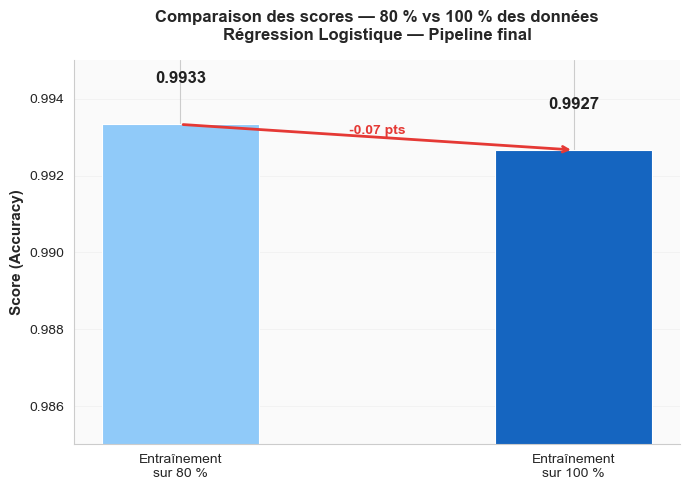

Graphique sauvegardé : comparaison_score_80_100.png ✓


In [74]:
#️⃣ ♦️ Graphique premium — comparaison score 80 % vs 100 %


labels  = ["Entraînement\nsur 80 %", "Entraînement\nsur 100 %"]
scores  = [lr.score(X_test_scaled, y_test), score_full]
colors  = ["#90caf9", "#1565c0"]

ecart        = (scores[1] - scores[0]) * 100
couleur_flec = "#2e7d32" if scores[1] >= scores[0] else "#e53935"

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("#FFFFFF")

bars = ax.bar(labels, scores, color=colors, width=0.4,
              edgecolor="white", linewidth=0.8)

#️⃣ Valeurs sur les barres
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.001,
            f"{val:.4f}",
            ha="center", va="bottom",
            fontsize=12, fontweight="bold",
            color="#212121")

#️⃣  Flèche gain ou perte
ax.annotate("",
            xy=(1, scores[1]),
            xytext=(0, scores[0]),
            arrowprops=dict(arrowstyle="->",
                            color=couleur_flec,
                            lw=2))
ax.text(0.5, (scores[0] + scores[1]) / 2,
        f"{ecart:+.2f} pts",
        ha="center", va="bottom",
        fontsize=10, color=couleur_flec,
        fontweight="bold")

#️⃣  Mise en forme
ax.set_ylim(0.985, 0.995)
ax.set_ylabel("Score (Accuracy)", fontsize=11, fontweight="bold")
ax.set_title("Comparaison des scores — 80 % vs 100 % des données\n"
             "Régression Logistique — Pipeline final",
             fontsize=12, fontweight="bold", pad=15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2, linewidth=0.6)
ax.set_facecolor("#fafafa")

plt.tight_layout()
plt.savefig("comparaison_score_80_100.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Graphique sauvegardé : comparaison_score_80_100.png ✓")

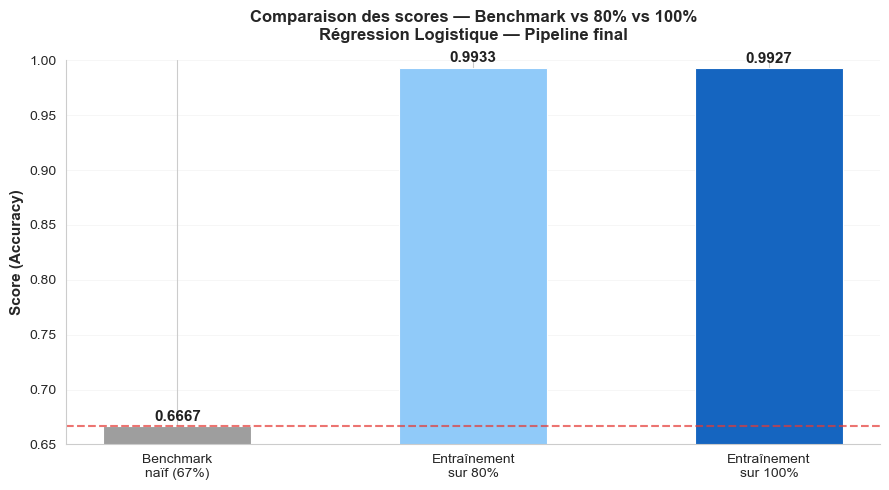

In [75]:
#️⃣ ♦️ Visualisation — Comparaison score 80% vs 100% des données + BENCHMARK

labels = ["Benchmark\nnaïf (67%)", "Entraînement\nsur 80%", "Entraînement\nsur 100%"]
scores = [0.6667, lr.score(X_test_scaled, y_test), score_full]
colors = ["#9e9e9e", "#90caf9", "#1565c0"]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#FFFFFF")

bars = ax.bar(labels, scores, color=colors, width=0.5, edgecolor="white", linewidth=0.8)

# Valeurs sur les barres
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f"{val:.4f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold", color="#212121")

# Axes et titres
ax.set_ylim(0.65, 1.00)
ax.set_ylabel("Score (Accuracy)", fontsize=11, fontweight="bold")
ax.set_title("Comparaison des scores — Benchmark vs 80% vs 100%\n"
             "Régression Logistique — Pipeline final",
             fontsize=12, fontweight="bold", pad=15)

# Ligne rouge à 67%
ax.axhline(y=0.6667, color="#e53935", linestyle="--", linewidth=1.5, alpha=0.7)

# Mise en forme
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2, linewidth=0.6)

plt.tight_layout()
plt.savefig("comparaison_scores_avec_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
C — Sauvegarde du pipeline
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Pourquoi sauvegarder le pipeline ?**

`joblib` sérialise l'objet Python complet — le pipeline entraîné avec **tous ses paramètres**.
Le fichier `.pkl` généré peut être rechargé dans n'importe quel script Python **sans réentraîner**.

C'est ce fichier que le **script de production** utilisera pendant la soutenance.

</div>

In [76]:
#️⃣ ♦️ Sauvegarde du pipeline entraîné

chemin_pipeline = "pipeline_detection_faux_billets.pkl"

joblib.dump(pipeline_production, chemin_pipeline)

taille = os.path.getsize(chemin_pipeline) / 1024
print(f"Pipeline sauvegardé : {chemin_pipeline}")
print(f"Taille du fichier   : {taille:.1f} Ko")
print()

#️⃣  Vérification : rechargement immédiat
pipeline_reload  = joblib.load(chemin_pipeline)
score_reload     = pipeline_reload.score(X_full, y_full)
print(f"Score après rechargement : {score_reload:.4f}")
print(f"Score avant sauvegarde   : {score_full:.4f}")
print()
print("Sauvegarde vérifiée ✓ — scores identiques")

Pipeline sauvegardé : pipeline_detection_faux_billets.pkl
Taille du fichier   : 1.9 Ko

Score après rechargement : 0.9927
Score avant sauvegarde   : 0.9927

Sauvegarde vérifiée ✓ — scores identiques


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
D — Chargement des billets de production
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Le fichier `billets_production.csv`**

Ce fichier contient des billets **non étiquetés** — leur nature (vrai/faux) est inconnue.
Il respecte exactement le même format que `billets.csv` : 6 variables géométriques, sans colonne `is_genuine`.

C'est ce fichier (ou un fichier de même format) qui sera fourni **pendant la soutenance**.

</div>

In [77]:
#️⃣ ♦️ Chargement des billets de production

features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

df_prod_final = pd.read_csv("billets_production.csv")

print(f"Billets de production chargés : {df_prod_final.shape[0]} billets")
print(f"Colonnes disponibles          : {list(df_prod_final.columns)}")
print(f"NaN éventuels                 : {df_prod_final.isnull().sum().sum()}")
print()
display(df_prod_final)

Billets de production chargés : 5 billets
Colonnes disponibles          : ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length', 'id']
NaN éventuels                 : 0



,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.7600,104.0100,103.5400,5.2100,3.3000,111.4200,A_1
1,171.8700,104.1700,104.1300,6.0000,3.3100,112.0900,A_2
2,172.0000,104.5800,104.2900,4.9900,3.3900,111.5700,A_3
3,172.4900,104.5500,104.3400,4.4400,3.0300,113.2000,A_4
4,171.6500,103.6300,103.5600,3.7700,3.1600,113.3300,A_5


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
Visualisation — Aperçu des 6 variables géométriques des 5 billets de production
</div>

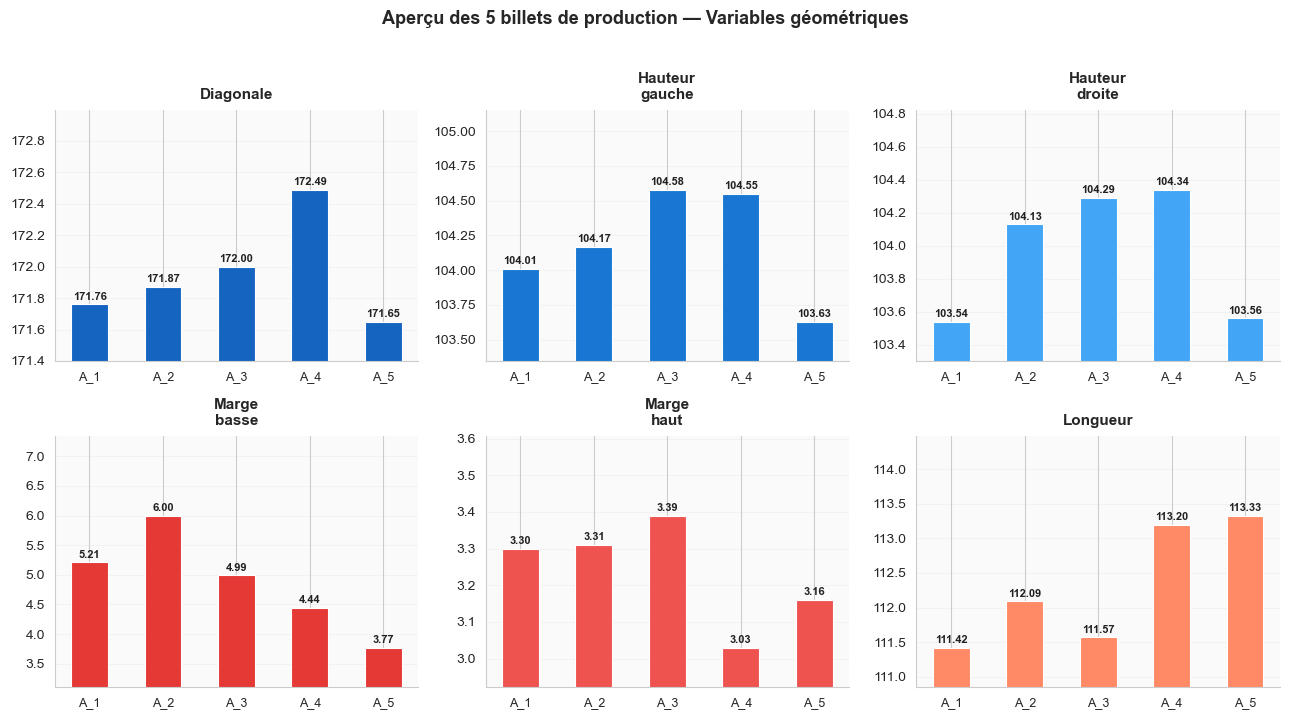

Graphique sauvegardé : apercu_billets_production.png ✓


In [78]:
#️⃣ ♦️ Graphique premium — aperçu des 5 billets de production

features_plot = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]
labels_plot   = ["Diagonale", "Hauteur\ngauche", "Hauteur\ndroite", "Marge\nbasse", "Marge\nhaut", "Longueur"]
ids           = df_prod_final["id"].values
colors        = ["#1565c0", "#1976d2", "#42a5f5", "#e53935", "#ef5350", "#ff8a65"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.patch.set_facecolor("#FFFFFF")
axes = axes.flatten()

for idx, (feat, label) in enumerate(zip(features_plot, labels_plot)):
    ax = axes[idx]
    valeurs = df_prod_final[feat].values

    bars = ax.bar(ids, valeurs, color=colors[idx],
                  edgecolor="white", linewidth=0.8, width=0.5)

    #️⃣  Valeurs sur les barres
    for bar, val in zip(bars, valeurs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (max(valeurs) - min(valeurs)) * 0.02,
                f"{val:.2f}",
                ha="center", va="bottom",
                fontsize=8, fontweight="bold", color="#212121")

    ax.set_title(label, fontsize=11, fontweight="bold", pad=8)
    ax.set_facecolor("#fafafa")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2, linewidth=0.6)
    ax.tick_params(axis="x", labelsize=9)

    #️⃣ Zoom sur les valeurs
    marge = (max(valeurs) - min(valeurs)) * 0.3
    ax.set_ylim(min(valeurs) - marge, max(valeurs) + marge * 2)

fig.suptitle("Aperçu des 5 billets de production — Variables géométriques",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("apercu_billets_production.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Graphique sauvegardé : apercu_billets_production.png ✓")

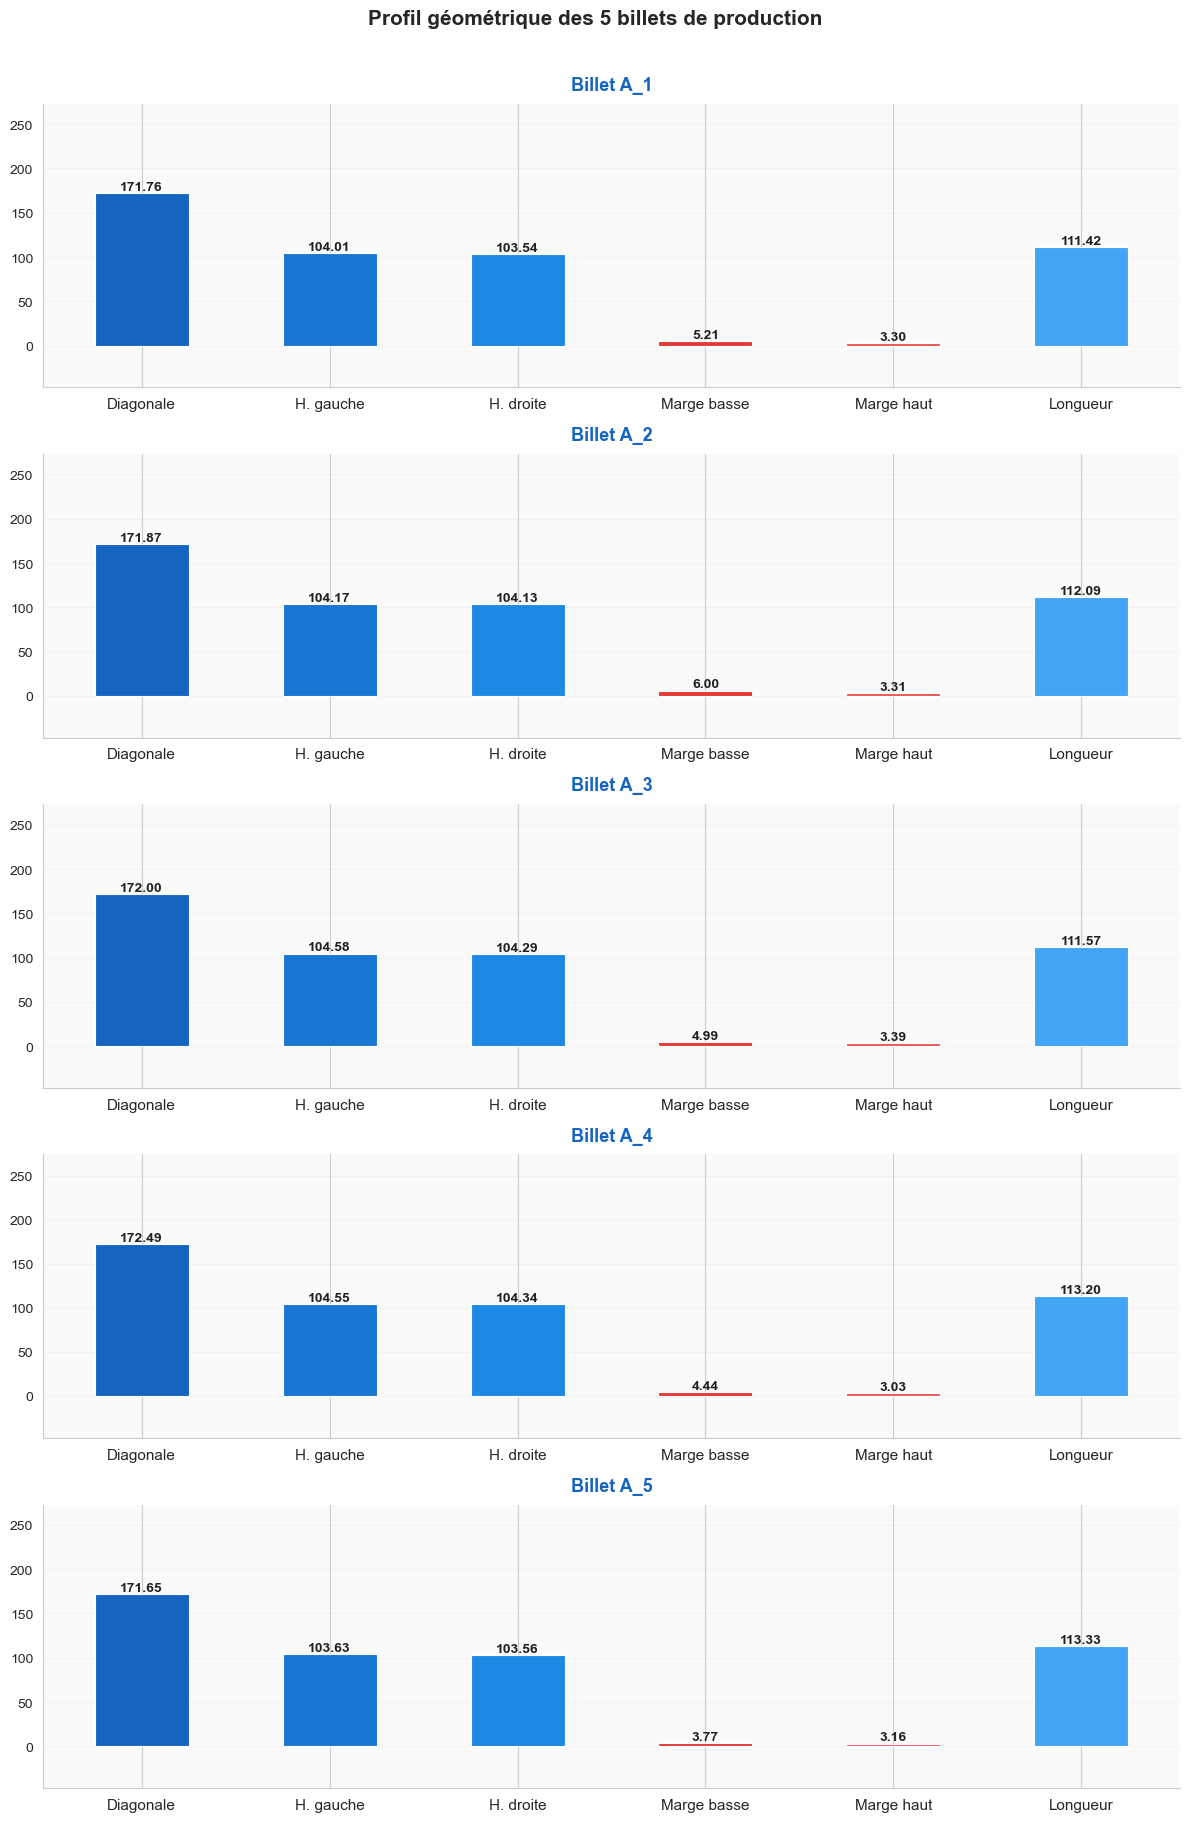

Graphique sauvegardé : profil_billets_production.png ✓


In [79]:
#️⃣ ♦️ Graphique premium — profil géométrique de chaque billet (version lisible)


features_plot = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]
labels_plot   = ["Diagonale", "H. gauche", "H. droite", "Marge basse", "Marge haut", "Longueur"]
ids           = df_prod_final["id"].values
colors        = ["#1565c0", "#1976d2", "#1e88e5", "#e53935", "#ef5350", "#42a5f5"]

fig, axes = plt.subplots(5, 1, figsize=(12, 18))
fig.patch.set_facecolor("#FFFFFF")

for idx, (billet_id, ax) in enumerate(zip(ids, axes)):
    valeurs = df_prod_final.loc[idx, features_plot].values.astype(float)

    bars = ax.bar(labels_plot, valeurs, color=colors,
                  edgecolor="white", linewidth=0.8, width=0.5)

    #️⃣  Valeurs sur les barres
    for bar, val in zip(bars, valeurs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f"{val:.2f}",
                ha="center", va="bottom",
                fontsize=10, fontweight="bold", color="#212121")

    ax.set_title(f"Billet {billet_id}",
                 fontsize=13, fontweight="bold",
                 pad=10, color="#1565c0")
    ax.set_facecolor("#fafafa")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2, linewidth=0.6)
    ax.tick_params(axis="x", labelsize=11)

    marge = (max(valeurs) - min(valeurs)) * 0.3
    ax.set_ylim(min(valeurs) - marge, max(valeurs) + marge * 2)

fig.suptitle("Profil géométrique des 5 billets de production",
             fontsize=15, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("profil_billets_production.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Graphique sauvegardé : profil_billets_production.png ✓")

<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px;">
E — Prédiction et résultats
</div>

<div style="background-color: #fff3cd; padding: 12px; border-left: 5px solid #f0ad4e; border-radius: 6px;">

**Ce que le pipeline produit pour chaque billet**

- **Classe prédite** : `Vrai` (1) ou `Faux` (0)
- **Probabilité d'être faux** : score entre 0 et 1 — plus il est proche de 1, plus le billet est suspect
- **Décision finale** : seuil à 0.5 (seuil par défaut de la Régression Logistique)

C'est cette sortie qui sera présentée **en live pendant la soutenance**.

</div>

In [80]:
#️⃣ ♦️ Prédiction sur les billets de production

X_prod = df_prod_final[features]

#️⃣  Prédictions
predictions  = pipeline_production.predict(X_prod)
probabilites = pipeline_production.predict_proba(X_prod)[:, 0]  # P(faux) = colonne 0

#️⃣  Tableau de résultats
df_resultats = df_prod_final.copy()
df_resultats["prediction"]     = predictions
df_resultats["nature"]         = df_resultats["prediction"].map({1: " VRAI", 0: " FAUX"})
df_resultats["proba_faux (%)"] = (probabilites * 100).round(2)

#️⃣ Affichage
print("=" * 55)
print("   RÉSULTATS — DÉTECTION DES FAUX BILLETS (ONCFM)")
print("=" * 55)

cols_affichage = ["id", "nature", "proba_faux (%)"] + features
display(df_resultats[cols_affichage])

print()
nb_faux  = (predictions == 0).sum()
nb_vrais = (predictions == 1).sum()
print(f" Vrais billets détectés : {nb_vrais}")
print(f" Faux billets détectés  : {nb_faux}")

   RÉSULTATS — DÉTECTION DES FAUX BILLETS (ONCFM)


,id,nature,proba_faux (%),diagonal,height_left,height_right,margin_low,margin_up,length
0,A_1,FAUX,99.9000,171.7600,104.0100,103.5400,5.2100,3.3000,111.4200
1,A_2,FAUX,99.9900,171.8700,104.1700,104.1300,6.0000,3.3100,112.0900
2,A_3,FAUX,99.9800,172.0000,104.5800,104.2900,4.9900,3.3900,111.5700
3,A_4,VRAI,2.0800,172.4900,104.5500,104.3400,4.4400,3.0300,113.2000
4,A_5,VRAI,0.0100,171.6500,103.6300,103.5600,3.7700,3.1600,113.3300



 Vrais billets détectés : 2
 Faux billets détectés  : 3


<div style="background-color: #e8f5e9; padding: 12px; border-left: 5px solid #2e7d32; border-radius: 6px; text-align: center;">
Visualisation — Probabilités de détection pour chaque billet
</div>

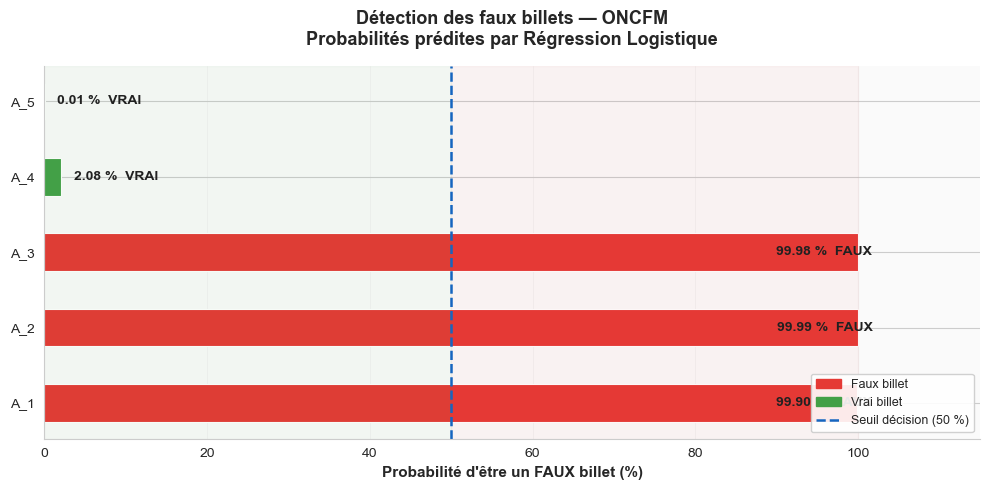

Graphique sauvegardé : resultats_production.png ✓


In [81]:
#️⃣ ♦️ Graphique premium — probabilités de faux billet par individu

ids         = df_resultats["id"].values
probas_faux = df_resultats["proba_faux (%)"].values
natures     = df_resultats["prediction"].values  # 1=vrai, 0=faux

colors = ["#e53935" if n == 0 else "#43a047" for n in natures]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#FFFFFF")

bars = ax.barh(ids, probas_faux, color=colors,
               height=0.5, edgecolor="white", linewidth=0.8)

#️⃣  Seuil de décision
ax.axvline(x=50, color="#1565c0", linewidth=1.8,
           linestyle="--", label="Seuil de décision (50 %)")

#️⃣  Zones
ax.axvspan(50, 100, alpha=0.04, color="#e53935")
ax.axvspan(0,  50,  alpha=0.04, color="#43a047")

#️⃣  Annotations VRAI / FAUX
for bar, val, nat, bid in zip(bars, probas_faux, natures, ids):
    label_nat = "FAUX" if nat == 0 else "VRAI"
    x_pos     = val + 1.5 if val < 90 else val - 10
    ax.text(x_pos,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f} %  {label_nat}",
            va="center", ha="left",
            fontsize=10, fontweight="bold",
            color="#212121")

#️⃣  Légende
patch_faux  = mpatches.Patch(color="#e53935", label="Faux billet")
patch_vrai  = mpatches.Patch(color="#43a047", label="Vrai billet")
ligne_seuil = plt.Line2D([0], [0], color="#1565c0",
                          linewidth=1.8, linestyle="--",
                          label="Seuil décision (50 %)")
ax.legend(handles=[patch_faux, patch_vrai, ligne_seuil],
          loc="lower right", fontsize=9, framealpha=0.9)

ax.set_xlabel("Probabilité d'être un FAUX billet (%)",
              fontsize=11, fontweight="bold")
ax.set_xlim(0, 115)
ax.set_title("Détection des faux billets — ONCFM\nProbabilités prédites par Régression Logistique",
             fontsize=13, fontweight="bold", pad=15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2, linewidth=0.6)
ax.set_facecolor("#fafafa")

plt.tight_layout()
plt.savefig("resultats_production.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Graphique sauvegardé : resultats_production.png ✓")